<a href="https://colab.research.google.com/github/isaacadebayo/Predictive_Analytics_and_NLP/blob/main/Time_Series_Financial_NYSE_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
stocks = pd.read_csv('/content/drive/MyDrive/prices.csv')
stocks.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05 0:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600
1,2016-01-06 0:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400
2,2016-01-07 0:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500
3,2016-01-08 0:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300
4,2016-01-11 0:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600


In [ ]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 45.5+ MB


"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

# Graphing Stock from 2010 to 2016. APPLE, AMAZON, GOOGLE etc.

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

In [ ]:
apple = stocks[stocks['symbol'] == 'AAPL']
apple.head()

,date,symbol,open,close,low,high,volume
254,2010-01-04,AAPL,213.429998,214.009998,212.380001,214.499996,123432400
721,2010-01-05,AAPL,214.599998,214.379993,213.249994,215.589994,150476200
1189,2010-01-06,AAPL,214.379993,210.969995,210.750004,215.230000,138040000
1657,2010-01-07,AAPL,211.750000,210.580000,209.050005,212.000006,119282800
2125,2010-01-08,AAPL,210.299994,211.980005,209.060005,212.000006,111902700


/tmp/ipykernel_1980/4184270901.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple['date'] = pd.to_datetime(apple['date'])


<Axes: xlabel='date'>

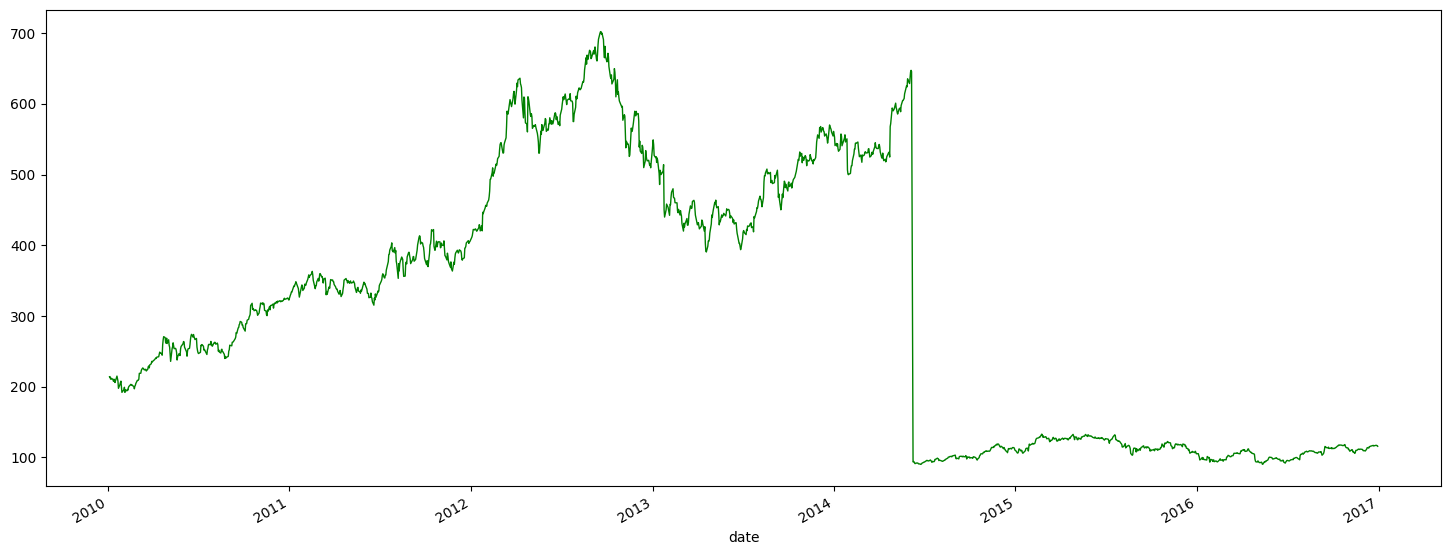

In [ ]:
apple['date'] = pd.to_datetime(apple['date'])
apple = apple.set_index('date')
apple.close.plot(figsize=(18,7), linewidth=1, c='g')

/tmp/ipykernel_1980/247013589.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  microsoft['date'] = pd.to_datetime(microsoft['date'])


<Axes: xlabel='date'>

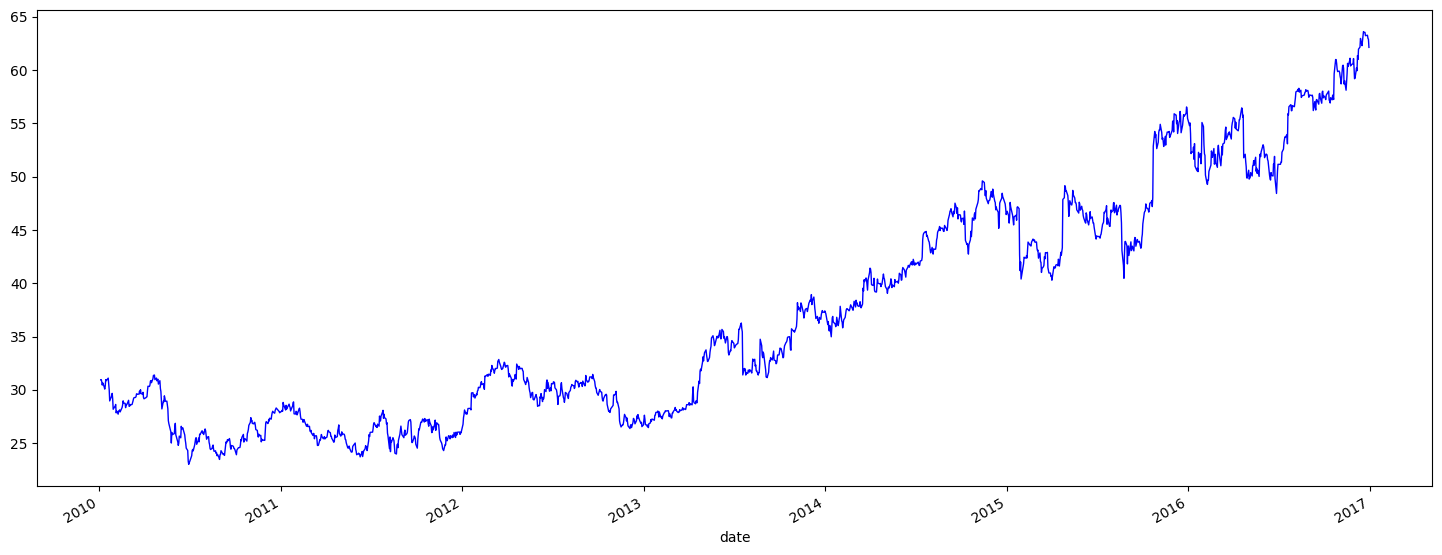

In [ ]:
microsoft = stocks[stocks['symbol'] == 'MSFT']
microsoft['date'] = pd.to_datetime(microsoft['date'])
microsoft = microsoft.set_index('date')
microsoft.close.plot(figsize=(18,7), linewidth=1, c='b')

/tmp/ipykernel_1980/2307724581.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  google['date'] = pd.to_datetime(google['date'])


<Axes: xlabel='date'>

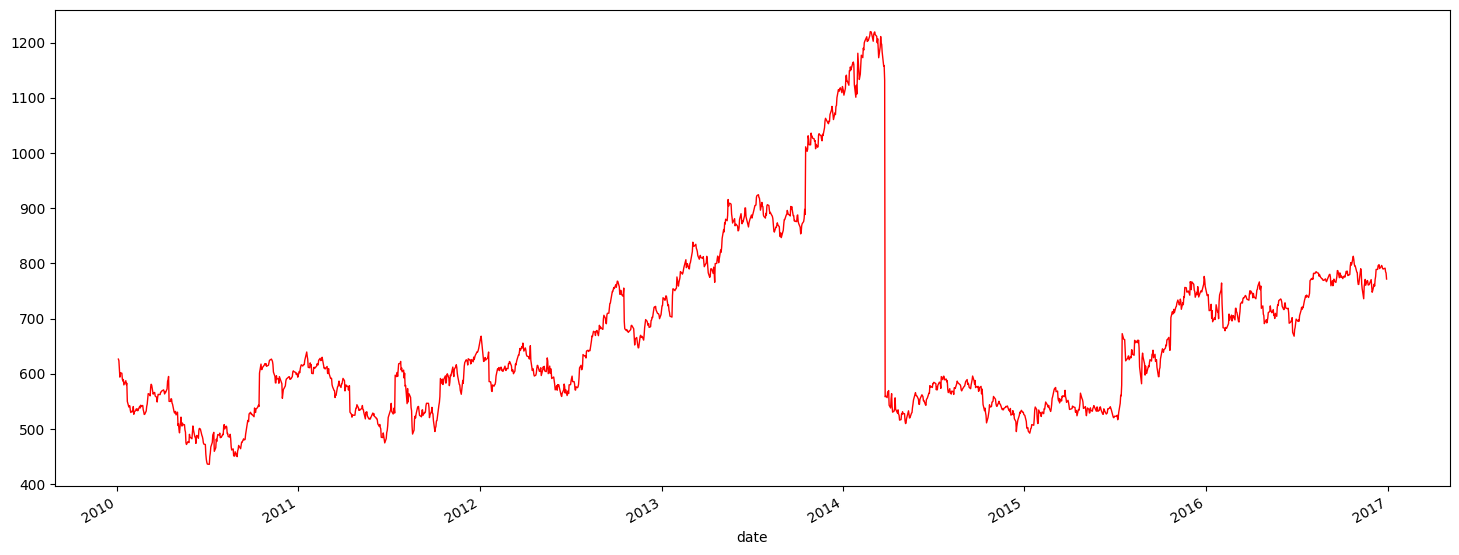

In [ ]:
google = stocks[stocks['symbol'] == 'GOOG']
google['date'] = pd.to_datetime(google['date'])
google = google.set_index('date')
google.close.plot(figsize=(18,7), linewidth=1, c='r')


/tmp/ipykernel_1980/3275162437.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Amazon['date'] = pd.to_datetime(Amazon['date'])


<Axes: xlabel='date'>

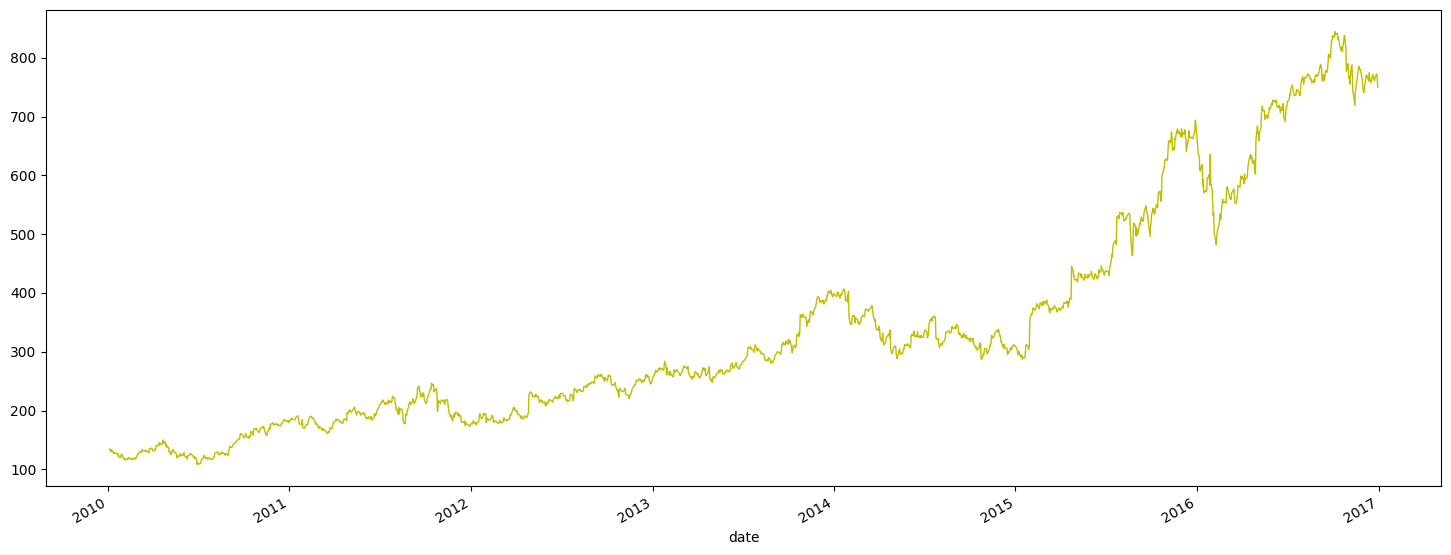

In [ ]:
Amazon = stocks[stocks['symbol'] == 'AMZN']
Amazon['date'] = pd.to_datetime(Amazon['date'])
Amazon = Amazon.set_index('date')
Amazon.close.plot(figsize=(18,7), linewidth=1, c='y')

In [ ]:
Amazon_dropped = Amazon.drop(columns=['symbol'])
Amazon_dropped.head()

,open,close,low,high,volume
date,,,,,
2010-01-04,136.250000,133.899994,133.139999,136.610001,7599900
2010-01-05,133.429993,134.690002,131.809998,135.479996,8851900
2010-01-06,134.600006,132.250000,131.649994,134.729996,7178800
2010-01-07,132.009995,130.000000,128.800003,132.320007,11030200
2010-01-08,130.559998,133.520004,129.029999,133.679993,9830500


# Scaling using MinMaxScaler

,count,mean,std,min,25%,50%,75%,max
open,1762.0,0.313499,0.255851,0.0,0.117634,0.238653,0.395338,1.0
close,1762.0,0.311640,0.257029,0.0,0.115212,0.236908,0.393347,1.0
low,1762.0,0.310519,0.255382,0.0,0.114977,0.236894,0.391943,1.0
high,1762.0,0.312771,0.258895,0.0,0.114472,0.236147,0.395141,1.0
volume,1762.0,0.087439,0.074609,0.0,0.042406,0.070138,0.106187,1.0


,open,close,low,high,volume
open,1.000000,0.999581,0.999764,0.999839,-0.237638
close,0.999581,1.000000,0.999832,0.999811,-0.238560
low,0.999764,0.999832,1.000000,0.999761,-0.243672
high,0.999839,0.999811,0.999761,1.000000,-0.233367
volume,-0.237638,-0.238560,-0.243672,-0.233367,1.000000


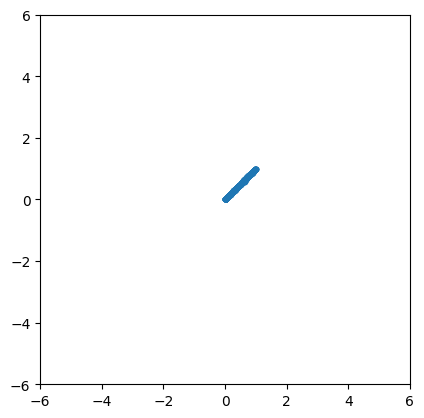

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(Amazon_dropped)

df_X_data = pd.DataFrame(X, columns=Amazon_dropped.columns)
display(df_X_data.describe().T)
display(df_X_data.corr())

plt.plot( X[:,0], X[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

"""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

# Create Sequence

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

In [ ]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X, y = [], []
dates = []
for i in range(len(Amazon_dropped) - window_size):
    #X.append(Amazon_dropped.iloc[i:i+window_size].values[perm])
    X.append(Amazon_dropped.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y.append(Amazon_dropped.iloc[i+window_size, 1])
    dates.append(Amazon_dropped.index[i+window_size])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (1752, 10, 5), y shape: (1752,)


X shape: There are 1732 sequence, each sequence has 30 steps (days) according to theee window size and 6 columns

Y shape: There aree 1752 target values, eeach value has 6 columns

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

# Train / test split for amazon (time series)

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

In [ ]:
# Simple index-based split
split_idx = int(len(X) * 0.8)
X_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]
X_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")

Train: X=(1401, 50), y=(1401,)
Test:  X=(351, 50), y=(351,)


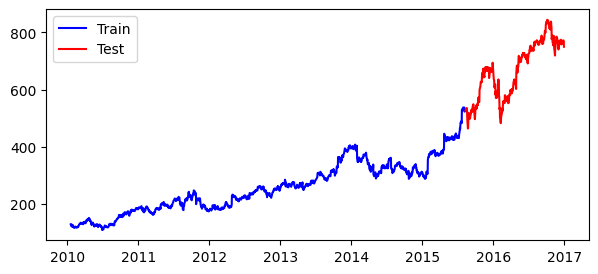

In [ ]:
plt.figure(figsize=(7,3))
# y_train and y_test are now 1D arrays
plt.plot( dates_train, y_train, 'b', label='Train' );
plt.plot( dates_test, y_test, 'r', label='Test' );
plt.legend()

Training will be blue and prediction will be red and I can go and check the price of AMAZON Stock seen in 2017 to see if prediction resemble real world

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

# Modelling using Sklearn

""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=4, weights='uniform'),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=30, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
]

# Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True)

# Reshape X to be 2-dimensional for scikit-learn models
X_2d = X.reshape(X.shape[0], -1)

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_2d, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.014974,0.001157,0.013961,0.013968,0.014526,0.016015,0.0164



KNeighborsRegressor(n_neighbors=4)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.482965,0.032089,0.441603,0.455028,0.502046,0.506972,0.509177



RandomForestRegressor(max_depth=5, n_estimators=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.017579,0.000938,0.016307,0.016995,0.017755,0.018185,0.018656



GradientBoostingRegressor()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.01662,0.000879,0.015204,0.016446,0.016881,0.017059,0.01751



GradientBoostingRegressor(max_depth=5)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.016083,0.000445,0.015386,0.016046,0.016152,0.016217,0.016615


# GridSearch CV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    )
}

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_2d, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.4451526544180088),
  'Best Params': {'n_neighbors': 50, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.015582941586239529),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 5,
   'min_samples_split': 5,
   'n_estimators': 50}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.015869753721237296),
  'Best Params': {'learning_rate': 0.1,
   'max_depth': 5,
   'min_samples_leaf': 2,
   'n_estimators': 100}}]

# Parsimony: Feature Importance

In [ ]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_2d, y)

# Generate feature names for X_2d
original_features = Amazon_dropped.columns.tolist()
feature_names_for_X_2d = []
for lag in range(window_size, 0, -1): # Lags from window_size down to 1
    for col in original_features:
        feature_names_for_X_2d.append(f'{col}_lag{lag}')

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names_for_X_2d).sort_values(ascending=False)
importances = importances[:100]

# Get the names of the selected features
features_rf = importances.index.tolist()

# Create a DataFrame from X_2d with the correct column names for easier slicing
X_2d_df = pd.DataFrame(X_2d, columns=feature_names_for_X_2d)

# Select only the important features from X_2d_df
X_pars = X_2d_df[features_rf]

importances

,0
close_lag1,0.316279
low_lag1,0.174367
open_lag1,0.145110
high_lag1,0.133232
low_lag2,0.060440
close_lag2,0.042395
open_lag2,0.040913
high_lag2,0.027756
close_lag3,0.018059
low_lag3,0.013435


<Axes: >

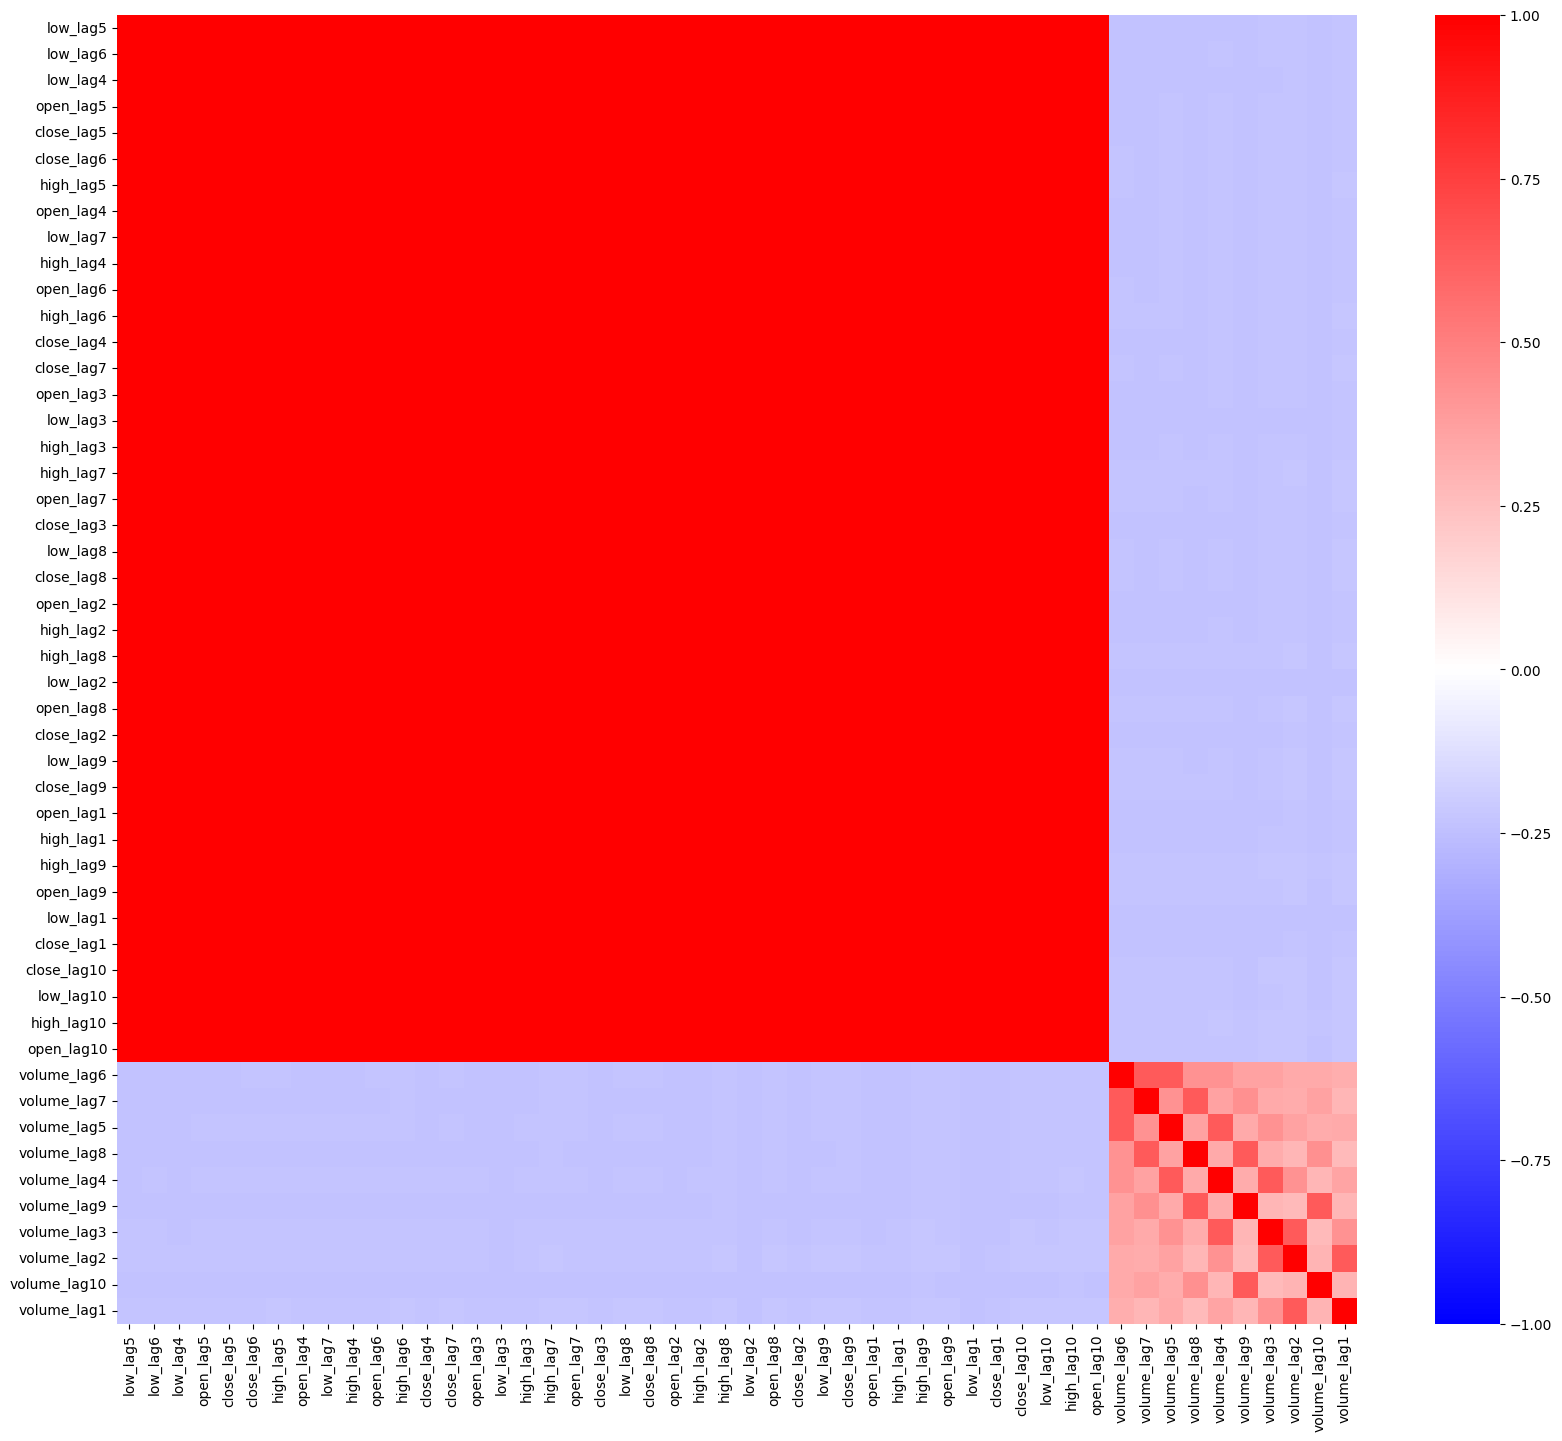

In [ ]:
corr = X_pars.corr()

# Sort columns by correlation for easy visuals
total_r2 = (corr**2).sum().sort_values(ascending=False)
sorted_columns = total_r2.index
corr = corr.loc[sorted_columns, sorted_columns]

plt.figure(figsize=(20, 17))
sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    cmap='bwr'
)

# Variance inflation factors

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_pars_with_const = sm.add_constant(X_pars)

vif = pd.Series(
    [variance_inflation_factor(X_pars_with_const.values, i) for i in range(X_pars_with_const.shape[1])],
    index=X_pars_with_const.columns
).sort_values(ascending=False)

vif[:25]

,0
high_lag5,12146.169011
high_lag6,12113.374427
high_lag4,12098.901178
high_lag7,12082.751970
high_lag2,12026.571292
high_lag8,12017.665707
high_lag3,12010.408449
high_lag9,11882.020154
high_lag1,11751.070520
high_lag10,11431.689118


Stock price is continuous so each variable should affect each other disregard ViF and I am not dropping any features

# Scale with Lasso

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_lasso = scaler.fit_transform(X_pars)

X_lasso_train, X_lasso_test, y_train, y_test = train_test_split(X_lasso, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error

# Define alpha values
alphas = np.linspace(1, 100000, 100)

# Initialize storage arrays
r2s_train = []
r2s_test  = []
mse_train = []
mse_test  = []
coefs     = []
non_zero  = []

for a in alphas:
    model = Lasso(alpha=a)  # Switch to Ridge(alpha=a) if needed

    model.fit(X_lasso_train, y_train)
    y_train_pred = model.predict(X_lasso_train)
    y_test_pred = model.predict(X_lasso_test)

    # Compute R² scores
    r2s_train.append(r2_score(y_train, y_train_pred))
    r2s_test.append(r2_score(y_test, y_test_pred))

    # Compute MSE
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))

    # Store coefficients
    coefs.append(model.coef_)

    # Get number of non-zero coefficients
    non_zero.append( (model.coef_ != 0).sum() )
# end

# Convert to NumPy arrays for efficient computation
r2s_train = np.array(r2s_train)
r2s_test  = np.array(r2s_test)
mse_train = np.array(mse_train)
mse_test  = np.array(mse_test)
coefs     = np.array(coefs)
non_zero  = np.array(non_zero)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.465e+03, tolerance: 4.859e+03
  model = cd_fast.enet_coordinate_descent(


# Creating plots for Lasso regression

/tmp/ipykernel_1980/1733441663.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


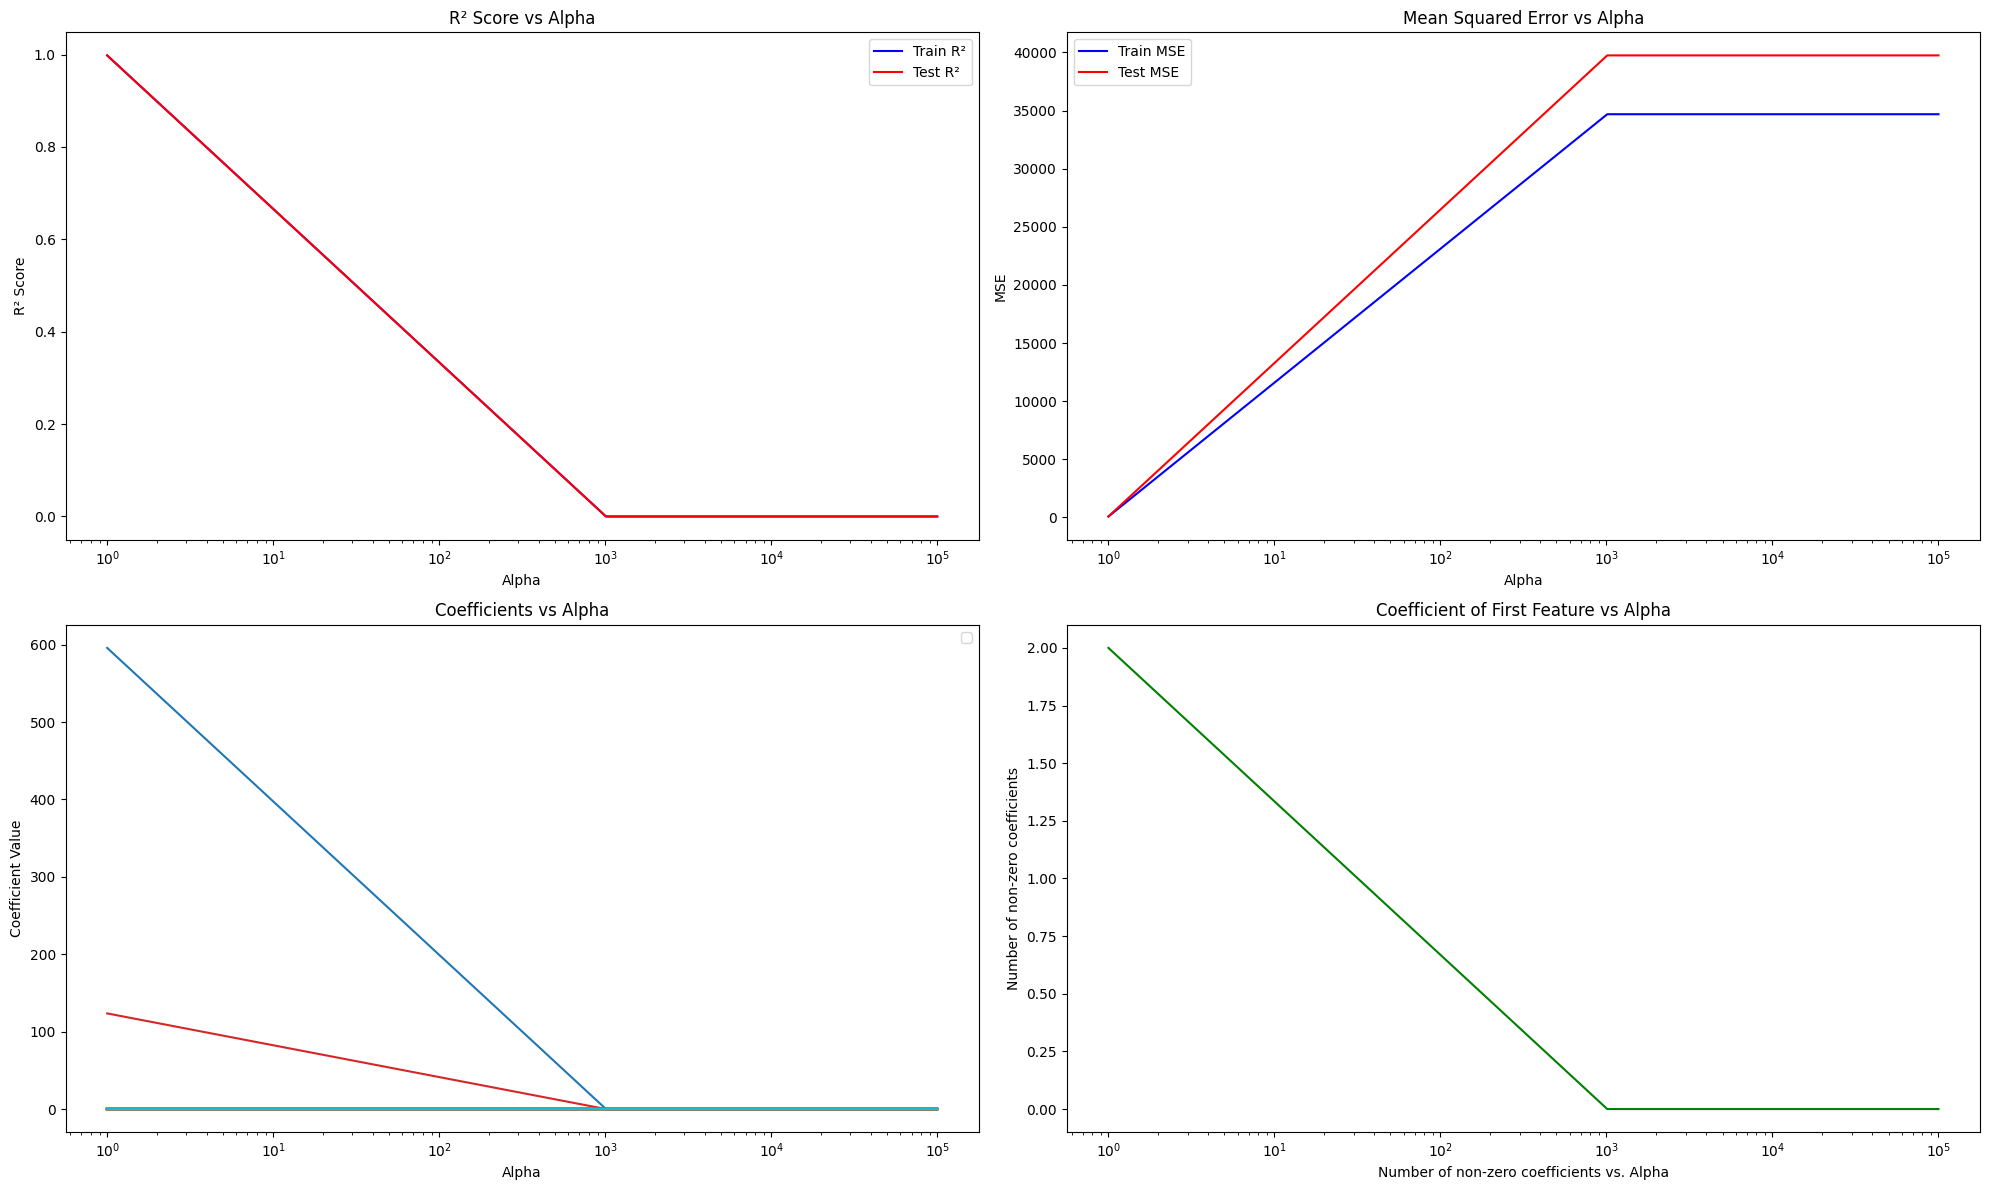

In [ ]:
# Create figure with 3 subplots side by side
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

# Plot R² scores (Train vs. Test)
axes[0].semilogx(alphas, r2s_train, 'b', label="Train R²")
axes[0].semilogx(alphas, r2s_test, 'r', label="Test R²")
axes[0].set_title("R² Score vs Alpha")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("R² Score")
axes[0].legend()

# Plot MSE values (Train vs. Test)
axes[1].semilogx(alphas, mse_train, 'b', label="Train MSE")
axes[1].semilogx(alphas, mse_test, 'r', label="Test MSE")
axes[1].set_title("Mean Squared Error vs Alpha")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("MSE")
axes[1].legend()

# Plot first feature's coefficients across alpha values
for i in range(coefs.shape[1]):
    axes[2].semilogx( alphas, coefs[:,i] )
# end
axes[2].set_title("Coefficients vs Alpha")
axes[2].set_xlabel("Alpha")
axes[2].set_ylabel("Coefficient Value")
axes[2].legend()

# Plot first feature's coefficients across alpha values
axes[3].semilogx(alphas, non_zero, 'g', label="Coef[0]")
axes[3].set_title("Coefficient of First Feature vs Alpha")
axes[3].set_xlabel("Number of non-zero coefficients vs. Alpha")
axes[3].set_ylabel("Number of non-zero coefficients")

# Adjust layout and show plot
plt.tight_layout()
plt.show()

LinearRegression()
r2_train:   0.99861
r2_test:    0.9984
rmse_train: 6.9375
rmse_test:  7.9806


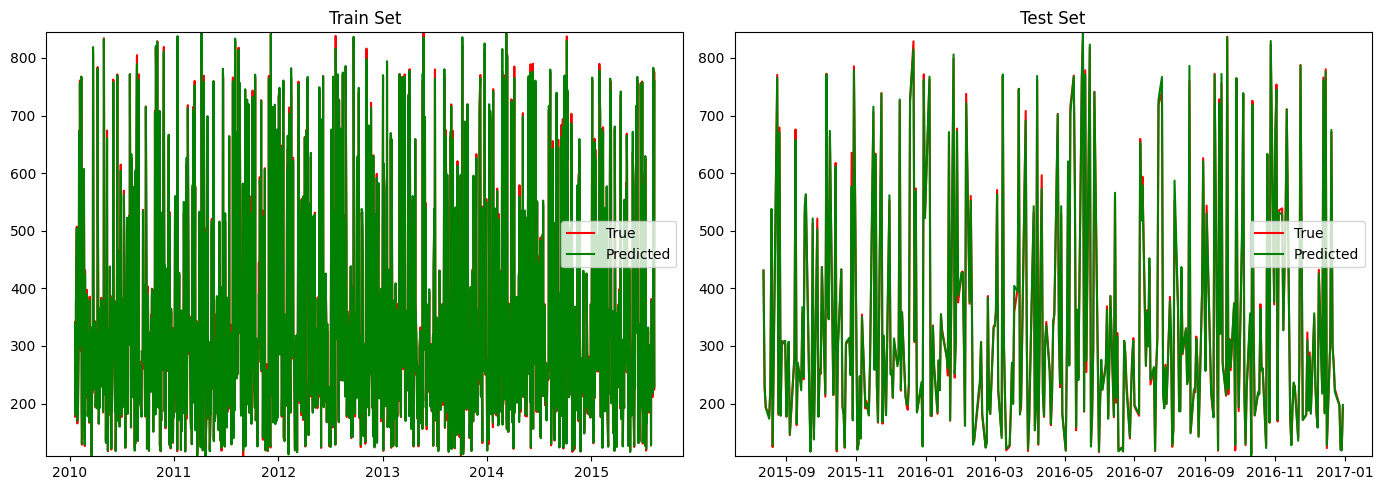

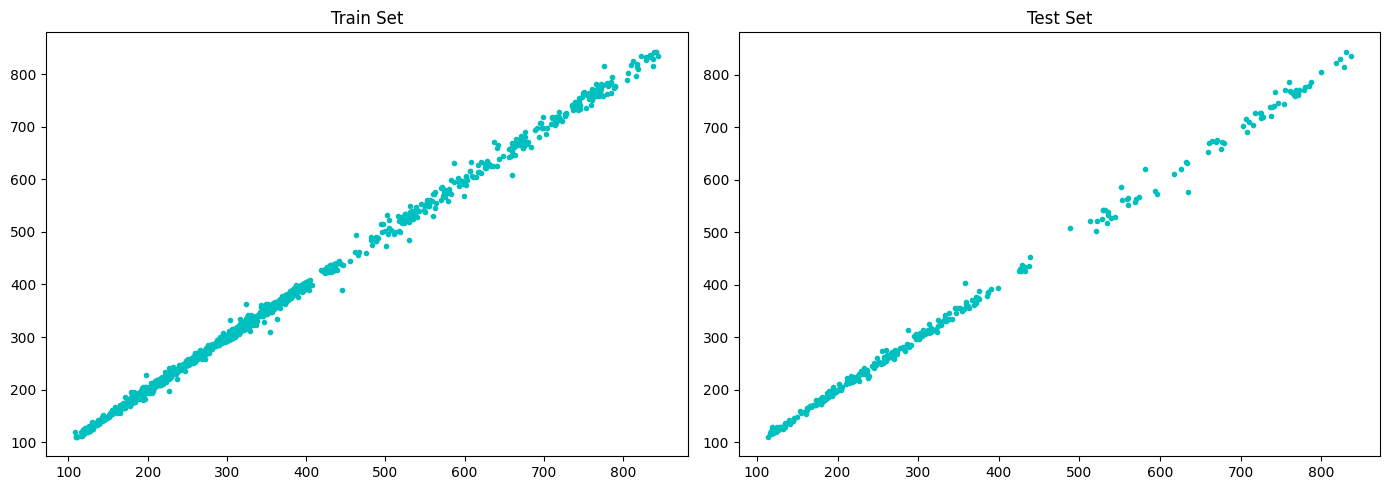


KNeighborsRegressor(n_neighbors=4)
r2_train:   0.99814
r2_test:    0.99659
rmse_train: 8.0217
rmse_test:  11.649


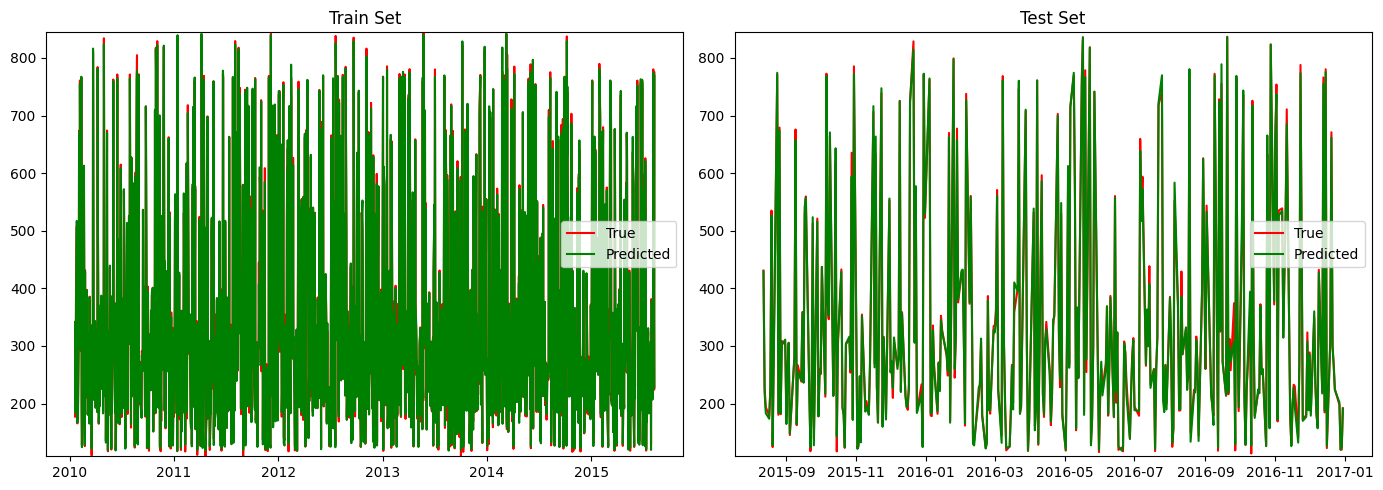

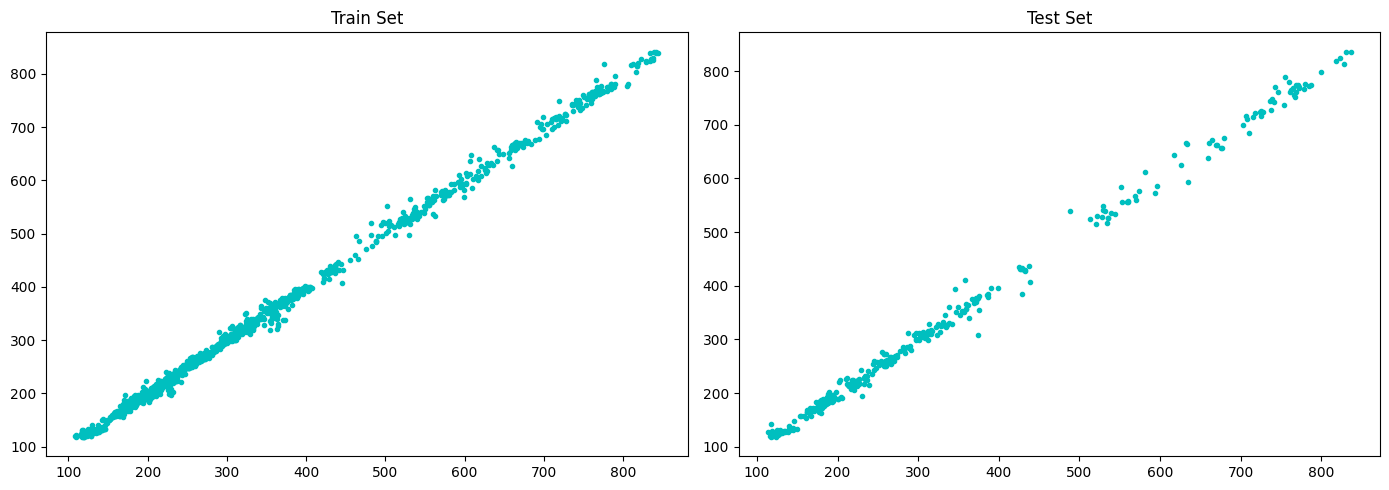


RandomForestRegressor(max_depth=5, n_estimators=10)
r2_train:   0.99875
r2_test:    0.99835
rmse_train: 6.5942
rmse_test:  8.0872


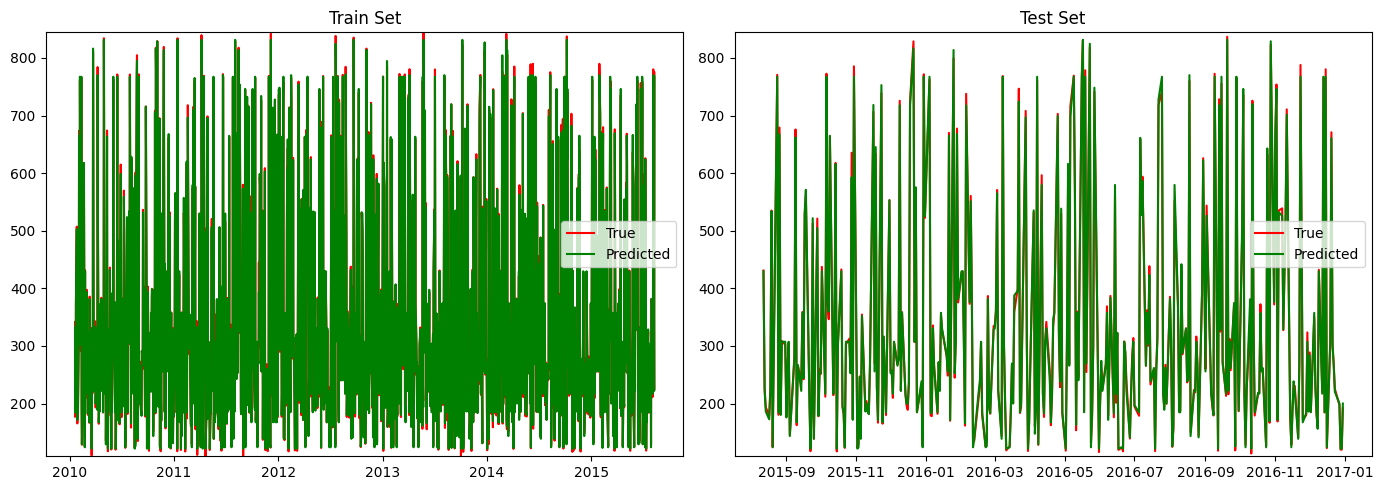

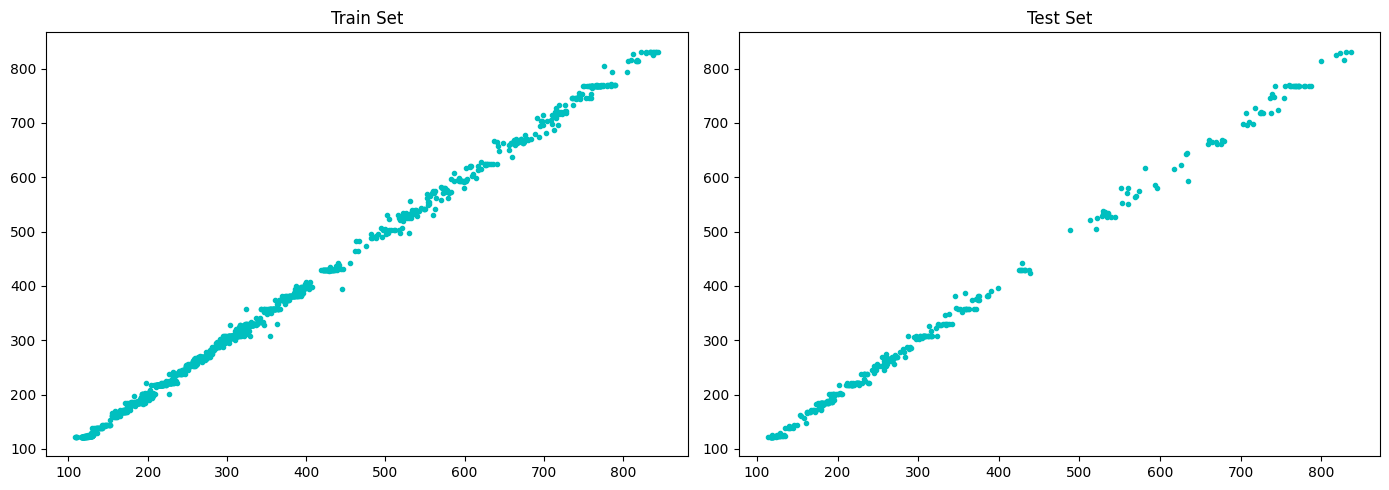


RandomForestRegressor(max_depth=10, n_estimators=30)
r2_train:   0.99966
r2_test:    0.99839
rmse_train: 3.4371
rmse_test:  7.9891


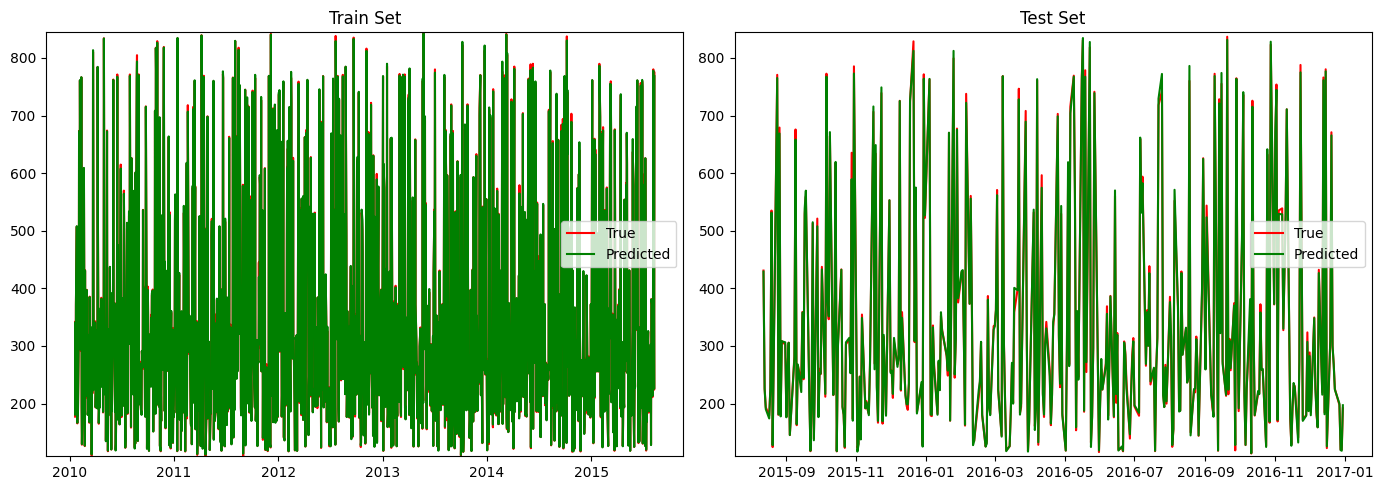

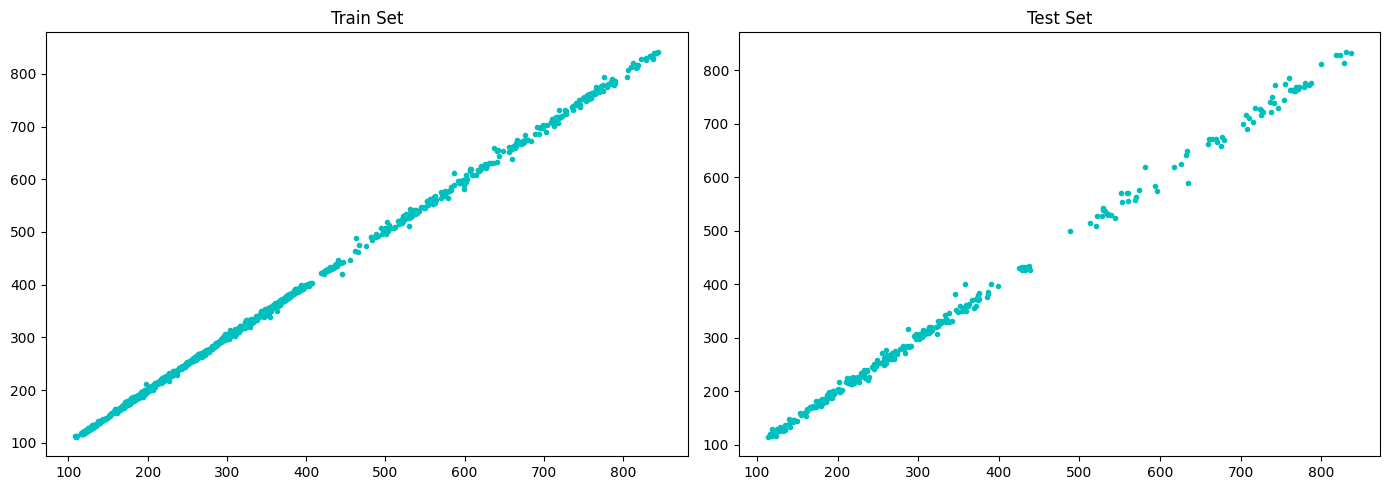


GradientBoostingRegressor(max_depth=2)
r2_train:   0.99913
r2_test:    0.99818
rmse_train: 5.4826
rmse_test:  8.5013


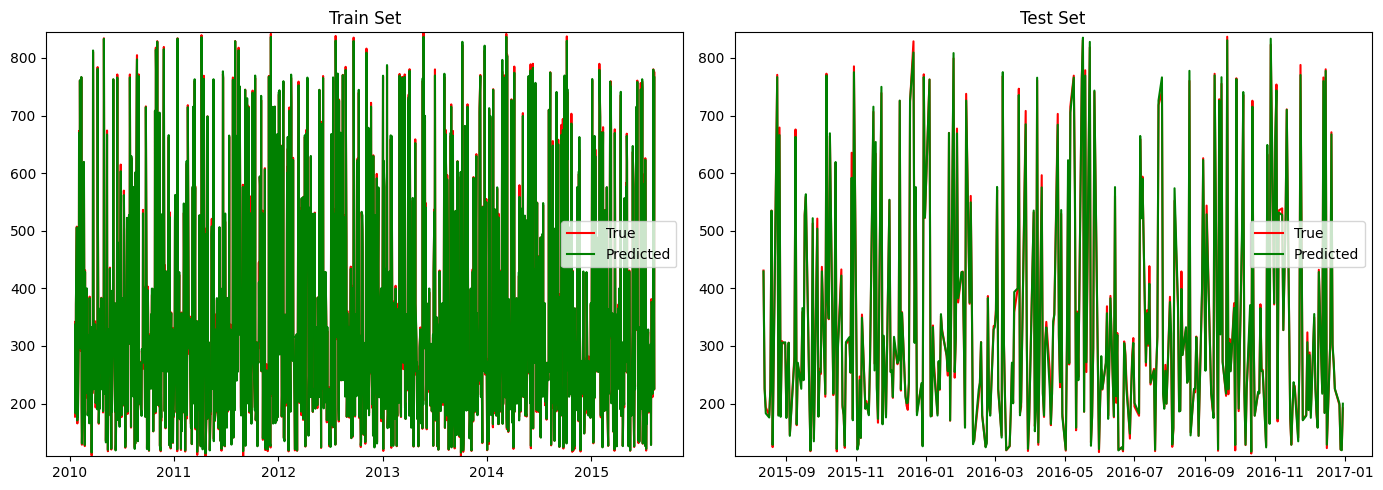

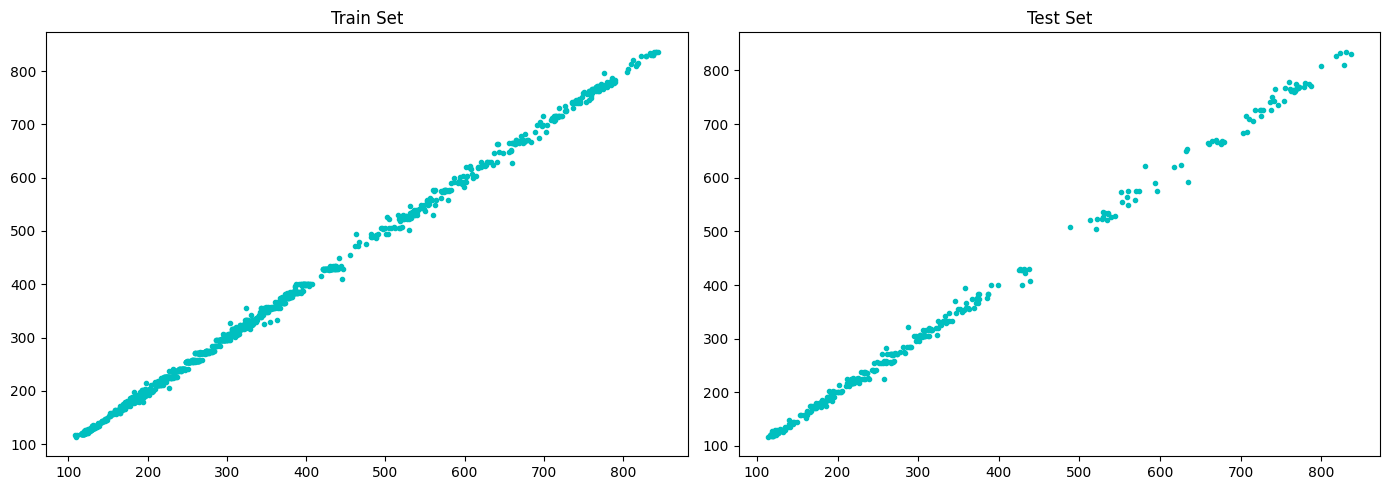


GradientBoostingRegressor()
r2_train:   0.99945
r2_test:    0.9984
rmse_train: 4.3842
rmse_test:  7.9698


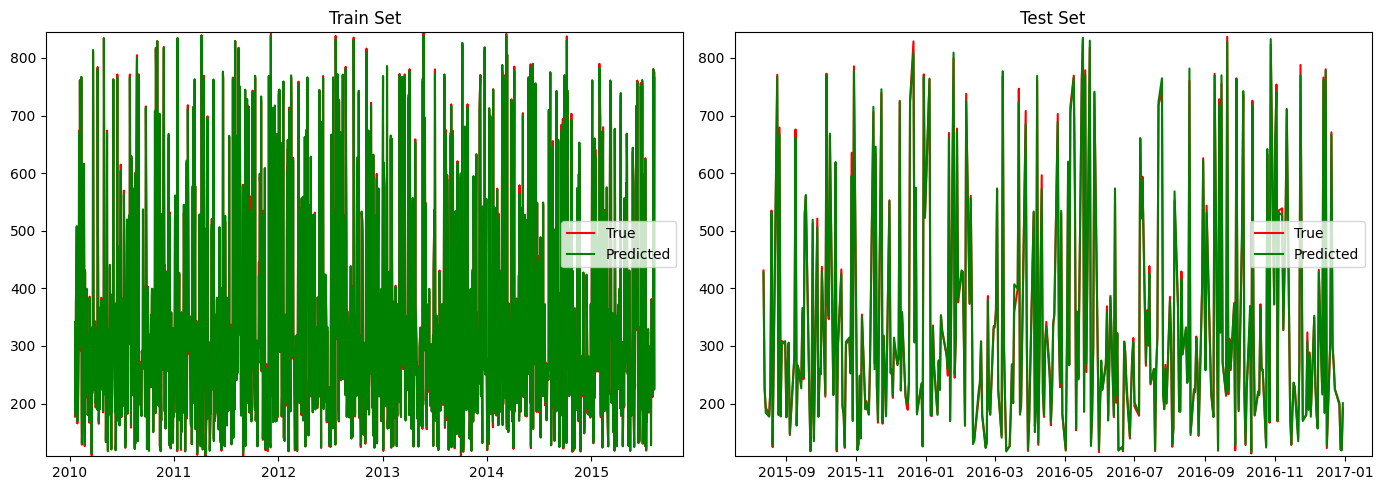

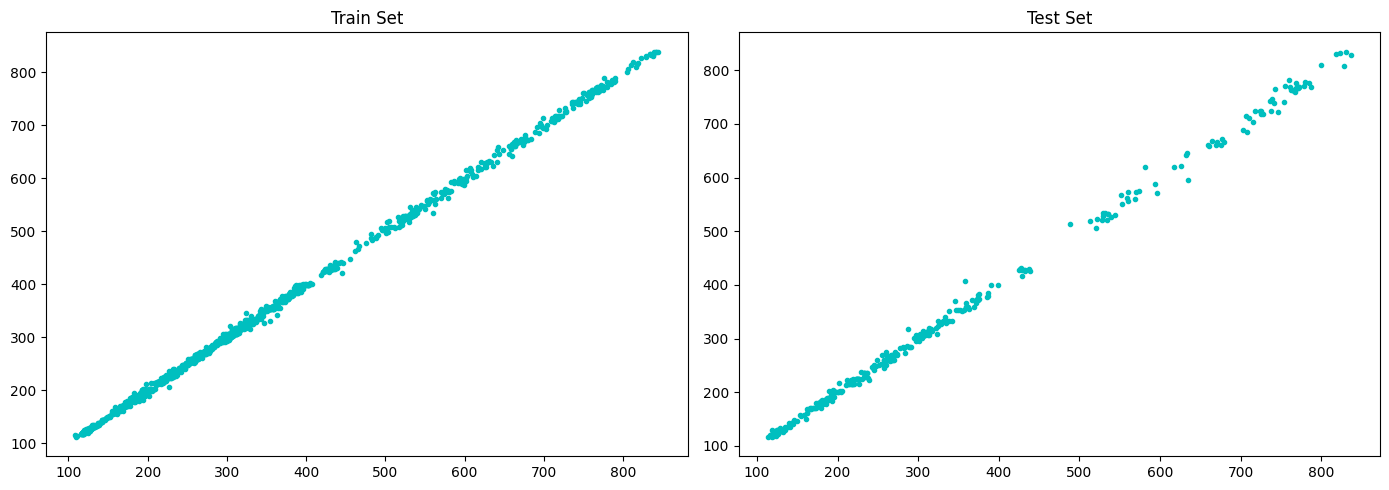


GradientBoostingRegressor(max_depth=5)
r2_train:   0.99985
r2_test:    0.99812
rmse_train: 2.3114
rmse_test:  8.643


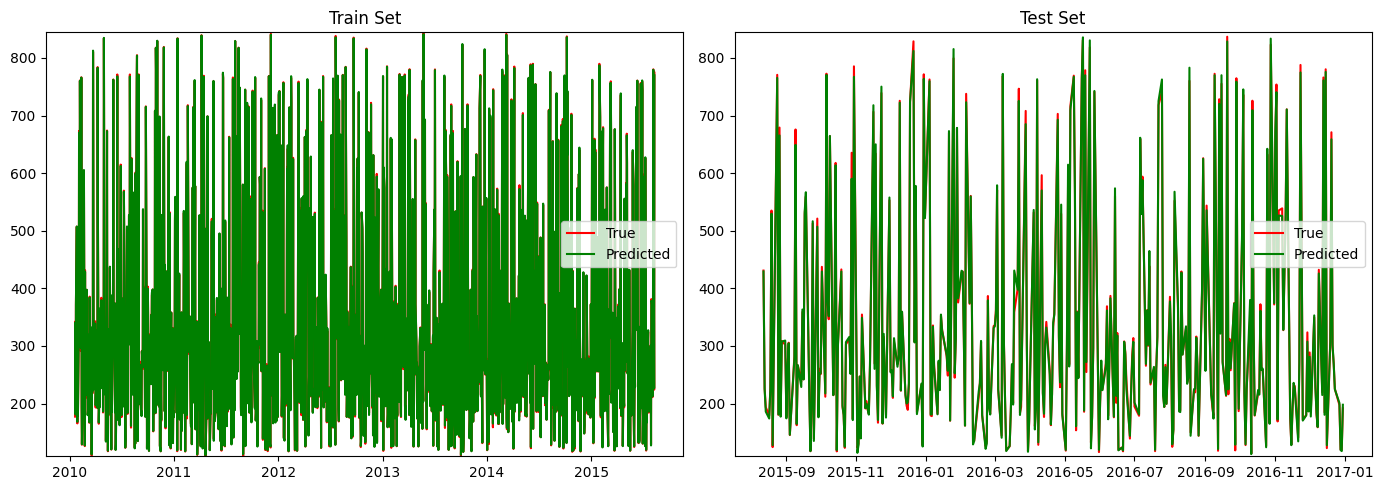

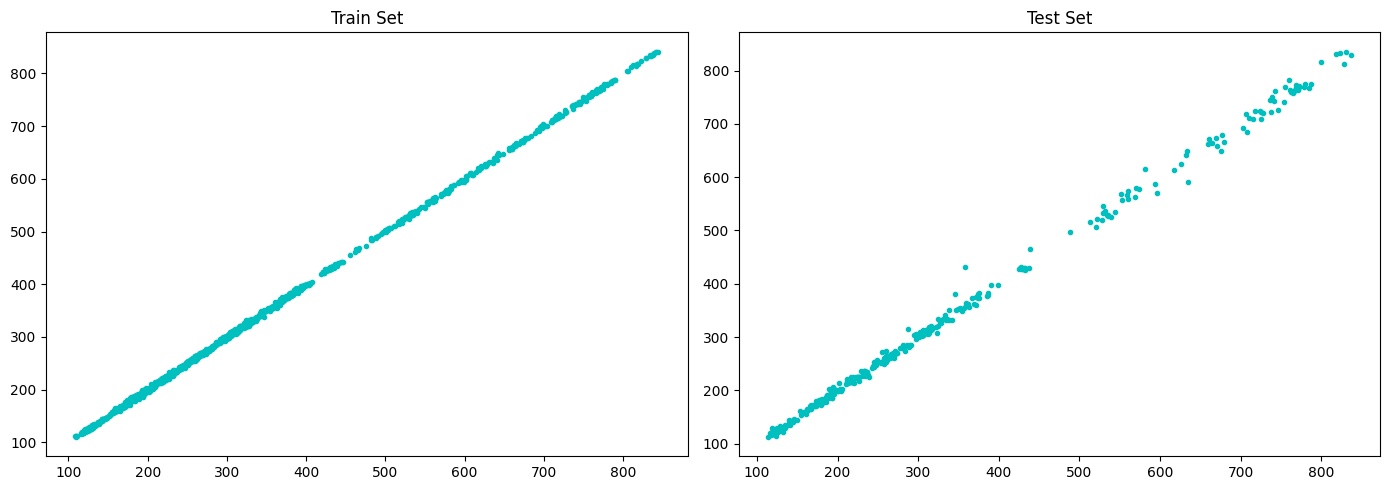

,r2_train,r2_test,rmse_train,rmse_test
model,,,,
LinearRegression(),0.998612,0.998397,6.937483,7.980559
KNeighborsRegressor(n_neighbors=4),0.998145,0.996585,8.021679,11.648717
"RandomForestRegressor(max_depth=5, n_estimators=10)",0.998746,0.998354,6.594167,8.087164
"RandomForestRegressor(max_depth=10, n_estimators=30)",0.999659,0.998394,3.437106,7.989080
GradientBoostingRegressor(max_depth=2),0.999133,0.998181,5.482612,8.501293
GradientBoostingRegressor(),0.999446,0.998402,4.384176,7.969837
GradientBoostingRegressor(max_depth=5),0.999846,0.998120,2.311351,8.643032


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Initialize list to hold results
results = []

for m in models:
    m.fit(X_lasso_train, y_train)

    y_train_pred = m.predict(X_lasso_train)
    y_test_pred  = m.predict(X_lasso_test)

    print(m)

    r2_train = r2_score(y_train, y_train_pred)
    print(f'r2_train:   {r2_train:.5}')

    r2_test = r2_score(y_test, y_test_pred)
    print(f'r2_test:    {r2_test:.5}')

    rmse_train = mean_squared_error(y_train, y_train_pred)**0.5
    print(f'rmse_train: {rmse_train:.5}')

    rmse_test = mean_squared_error(y_test, y_test_pred)**0.5
    print(f'rmse_test:  {rmse_test:.5}')

    # Store in results list
    results.append({
        'model': str(m),
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    })

    # Since y_train_pred and y_test_pred are now 1D, we can directly create pd.Series
    y_train_pred_series = pd.Series(y_train_pred, index=dates_train)
    y_test_pred_series  = pd.Series(y_test_pred, index=dates_test)

    # Calculate global y-axis limits (y_train and y_test are now 1D)
    y_min = min(y_train.min(), y_train_pred_series.min(), y_test.min(), y_test_pred_series.min())
    y_max = max(y_train.max(), y_train_pred_series.max(), y_test.max(), y_test_pred_series.max())

    # Plot train and test side by side with shared y limits
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(dates_train, y_train, 'r', label='True')
    axs[0].plot(y_train_pred_series, 'g', label='Predicted')
    axs[0].set_title('Train Set')
    axs[0].set_ylim(y_min, y_max)
    axs[0].legend()

    axs[1].plot(dates_test, y_test, 'r', label='True')
    axs[1].plot(y_test_pred_series, 'g', label='Predicted')
    axs[1].set_title('Test Set')
    axs[1].set_ylim(y_min, y_max)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Plot train and test side by side with shared y limits
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(y_train, y_train_pred, 'c.')
    axs[0].set_title('Train Set')
    # Removed redundant legend call as no labels are defined for scatter plot
    # axs[0].legend()

    axs[1].plot(y_test, y_test_pred, 'c.')
    axs[1].set_title('Test Set')
    # Removed redundant legend call as no labels are defined for scatter plot
    # axs[1].legend()

    plt.tight_layout()
    plt.show()

    print()
# end

# Create DataFrame
results_df = pd.DataFrame(results)

# Show or sort results
results_df = results_df.set_index("model")
results_df

# Createe plot without Lasso Regression

LinearRegression()
r2_train:   0.99861
r2_test:    0.9984
rmse_train: 6.9375
rmse_test:  7.9806


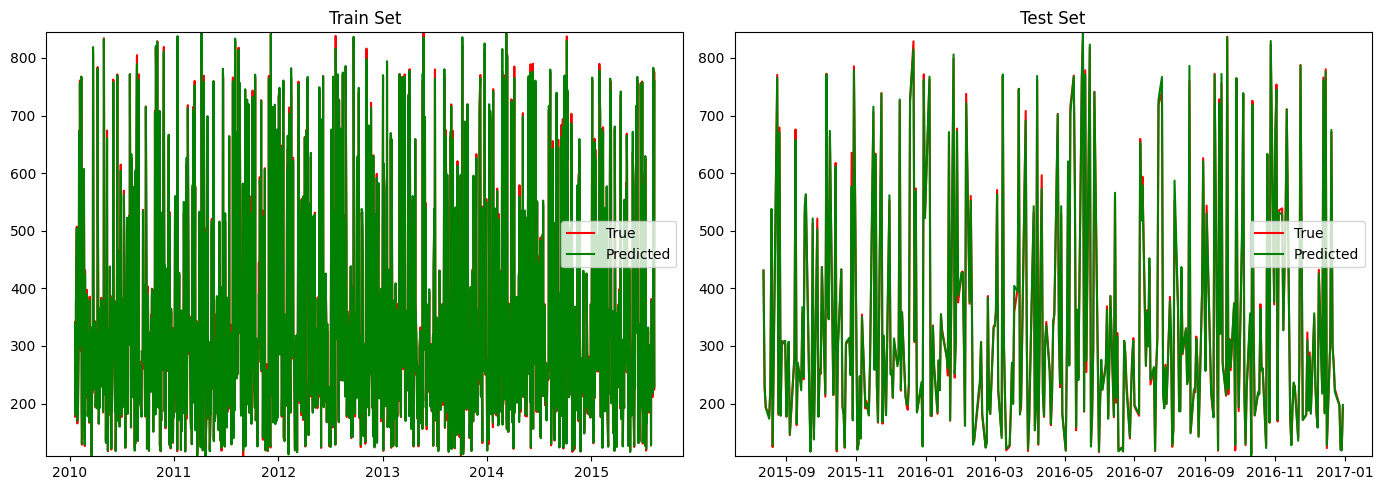

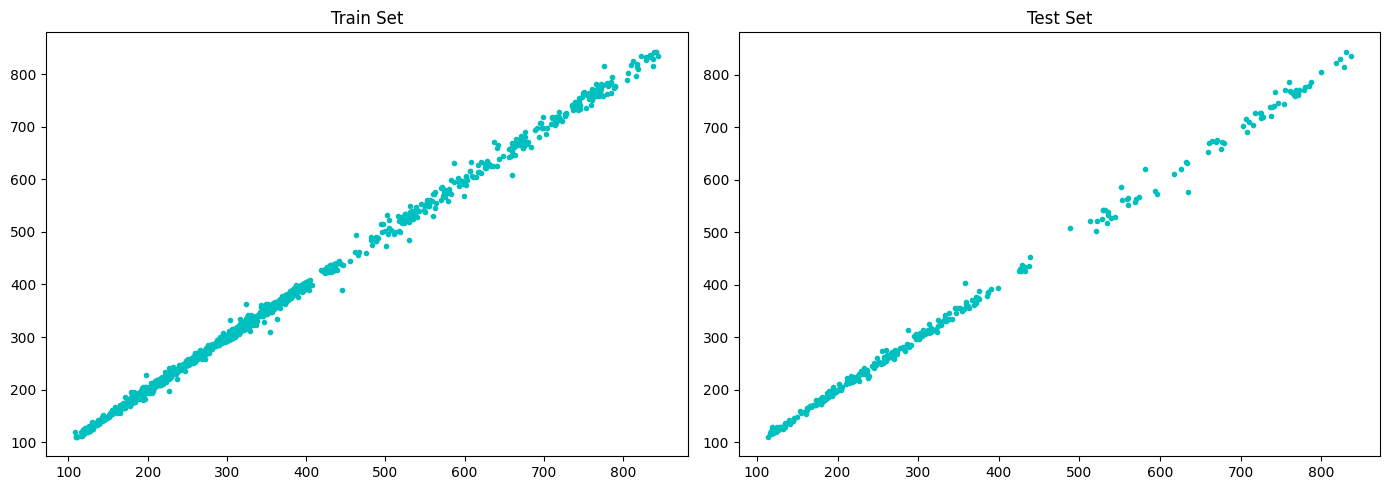


KNeighborsRegressor(n_neighbors=4)
r2_train:   0.99814
r2_test:    0.99659
rmse_train: 8.0217
rmse_test:  11.649


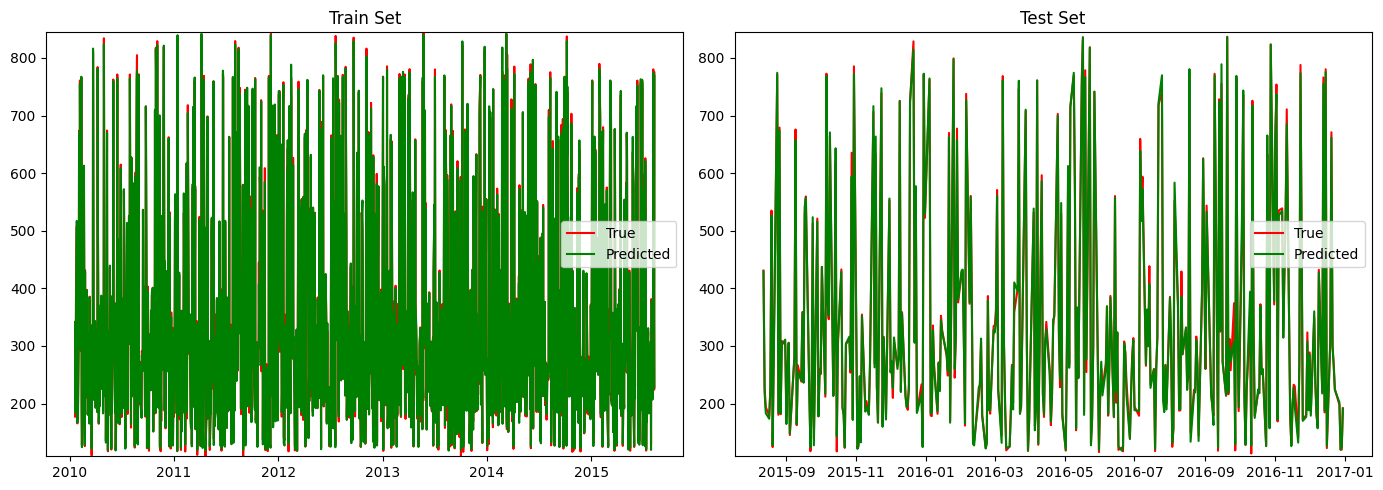

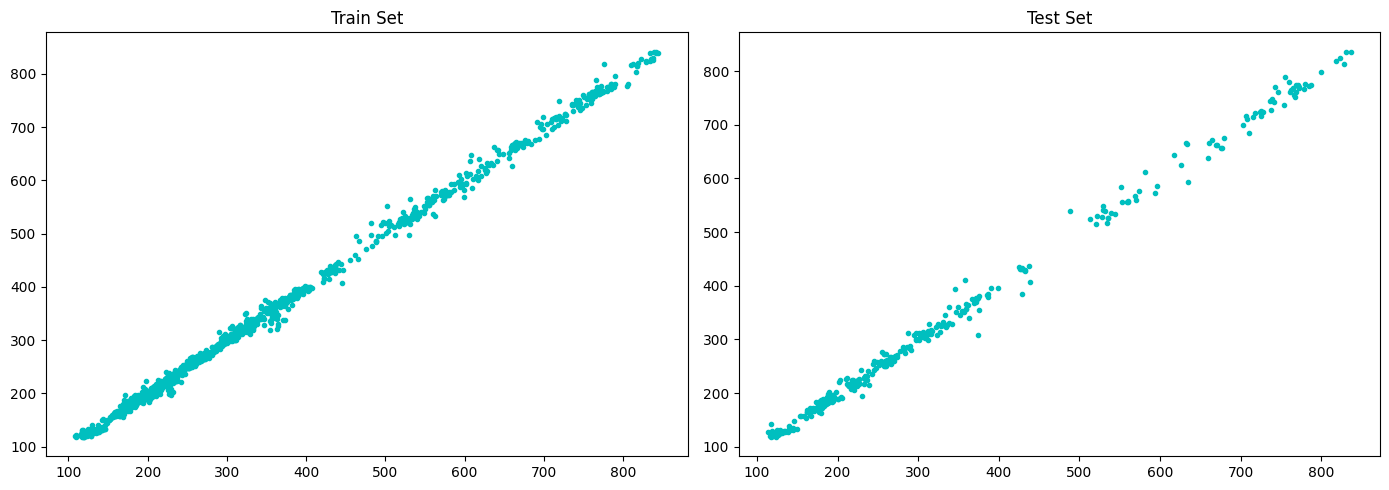


RandomForestRegressor(max_depth=5, n_estimators=10)
r2_train:   0.99874
r2_test:    0.9984
rmse_train: 6.6176
rmse_test:  7.9635


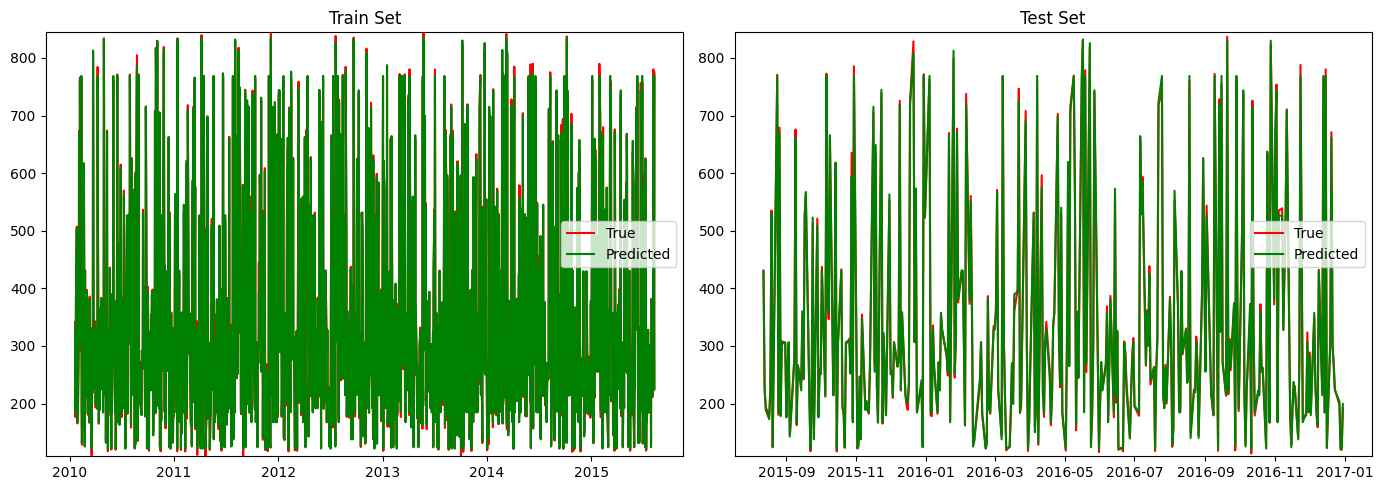

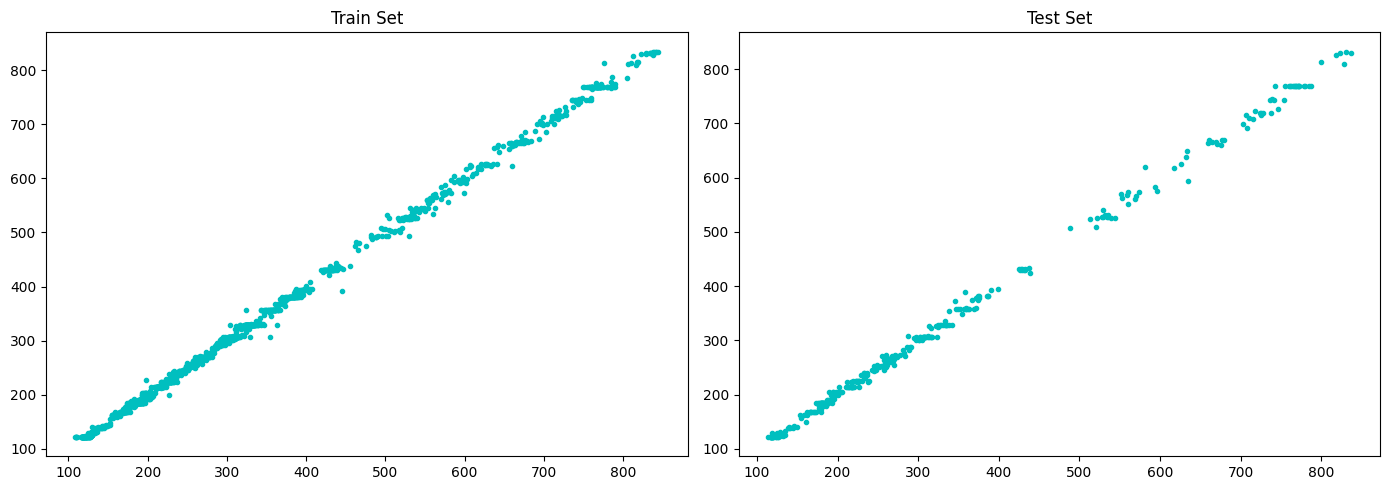


RandomForestRegressor(max_depth=10, n_estimators=30)
r2_train:   0.99969
r2_test:    0.99839
rmse_train: 3.2671
rmse_test:  7.9957


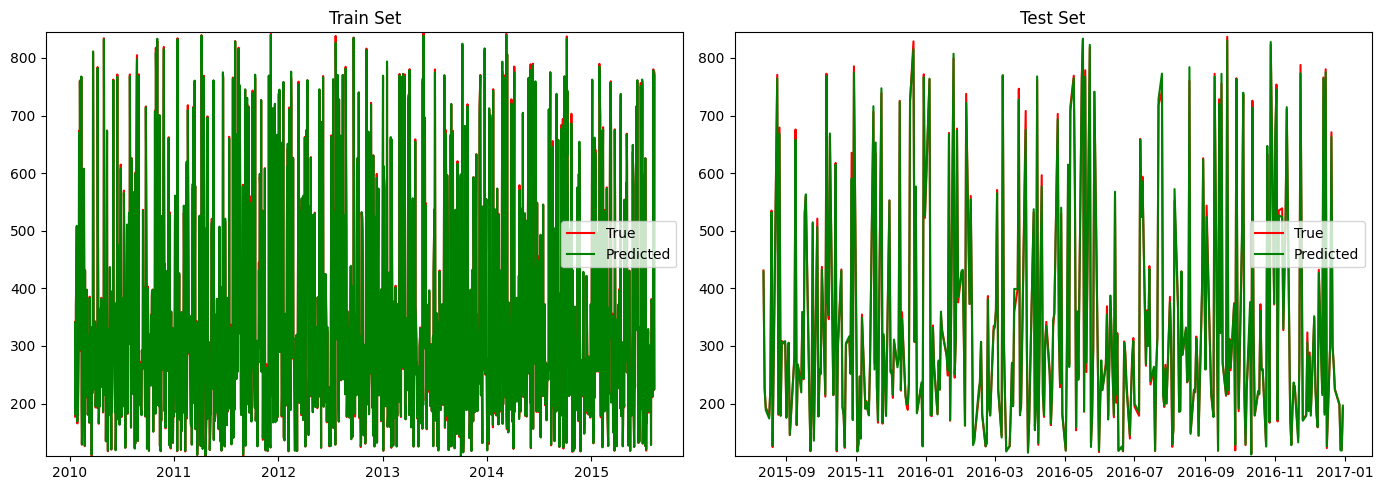

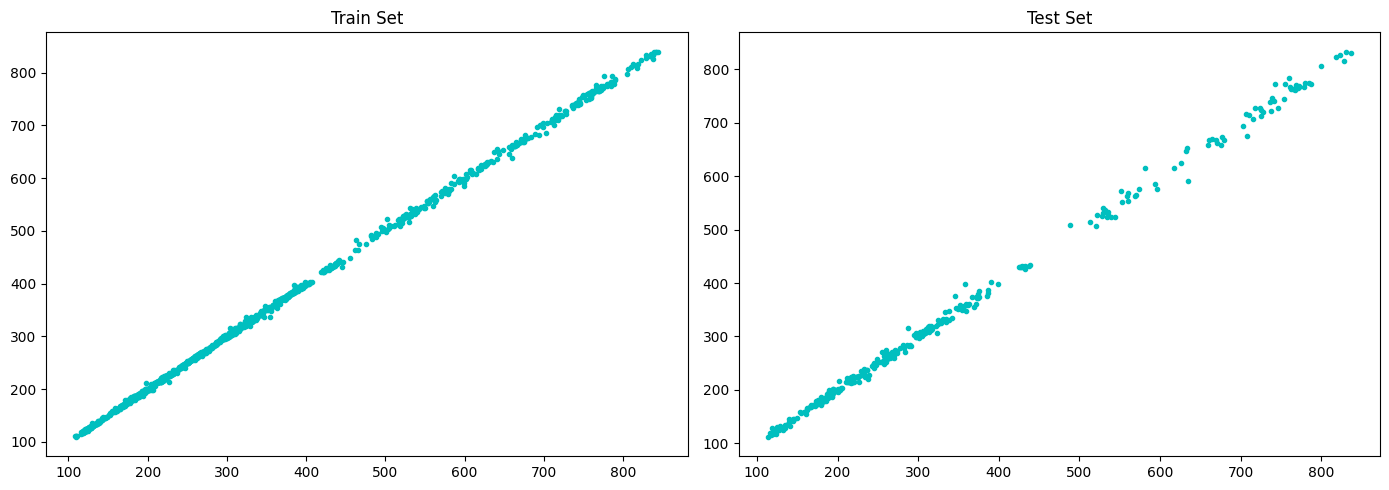


GradientBoostingRegressor(max_depth=2)
r2_train:   0.99913
r2_test:    0.99824
rmse_train: 5.4826
rmse_test:  8.3626


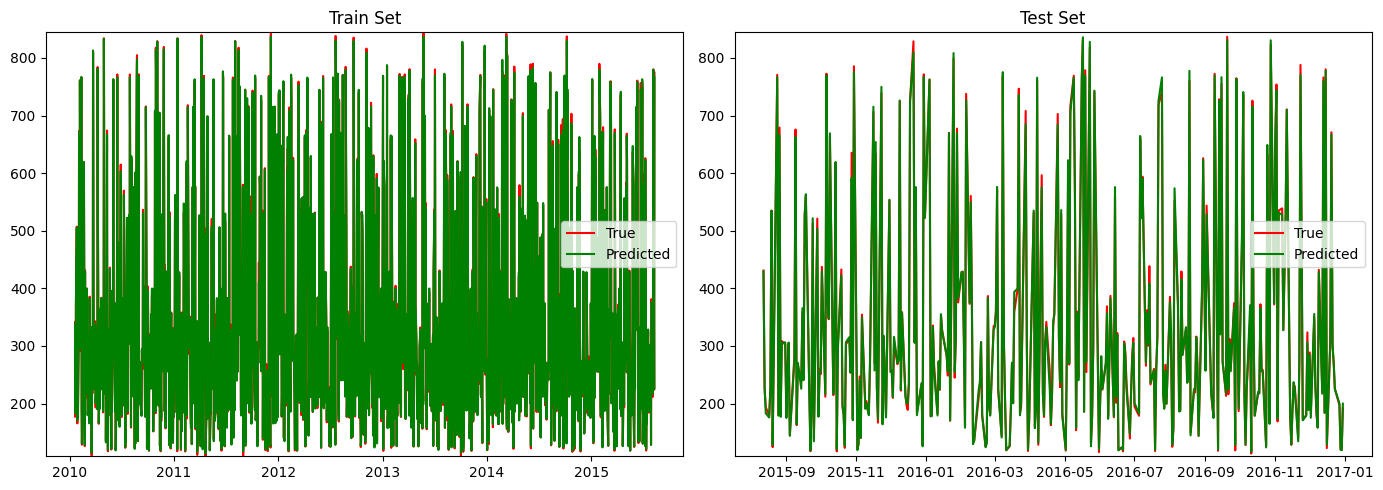

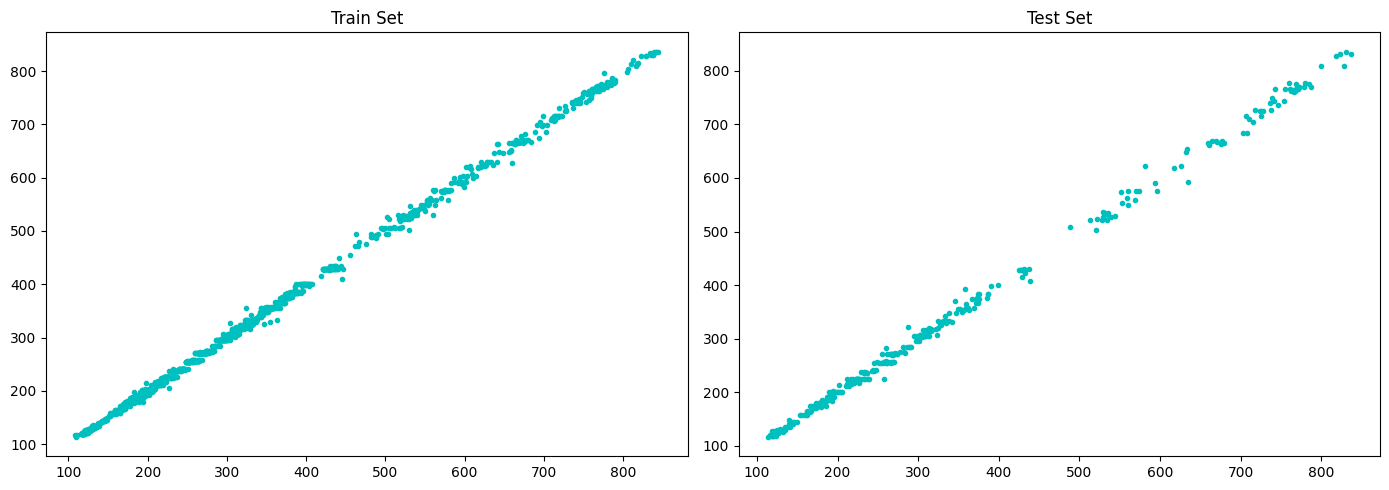


GradientBoostingRegressor()
r2_train:   0.99945
r2_test:    0.99843
rmse_train: 4.3842
rmse_test:  7.896


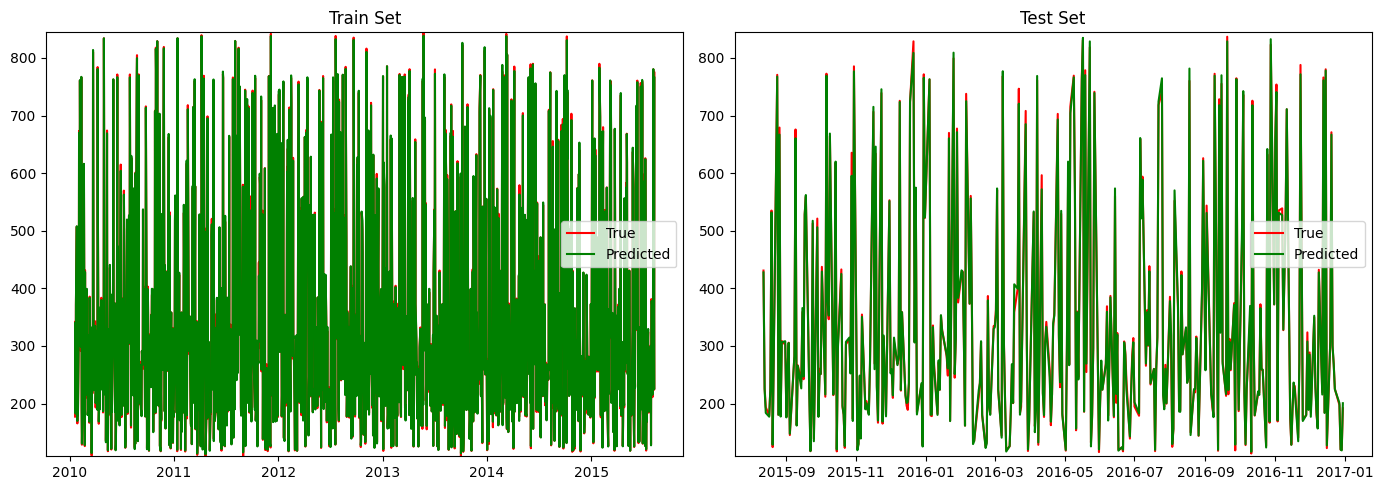

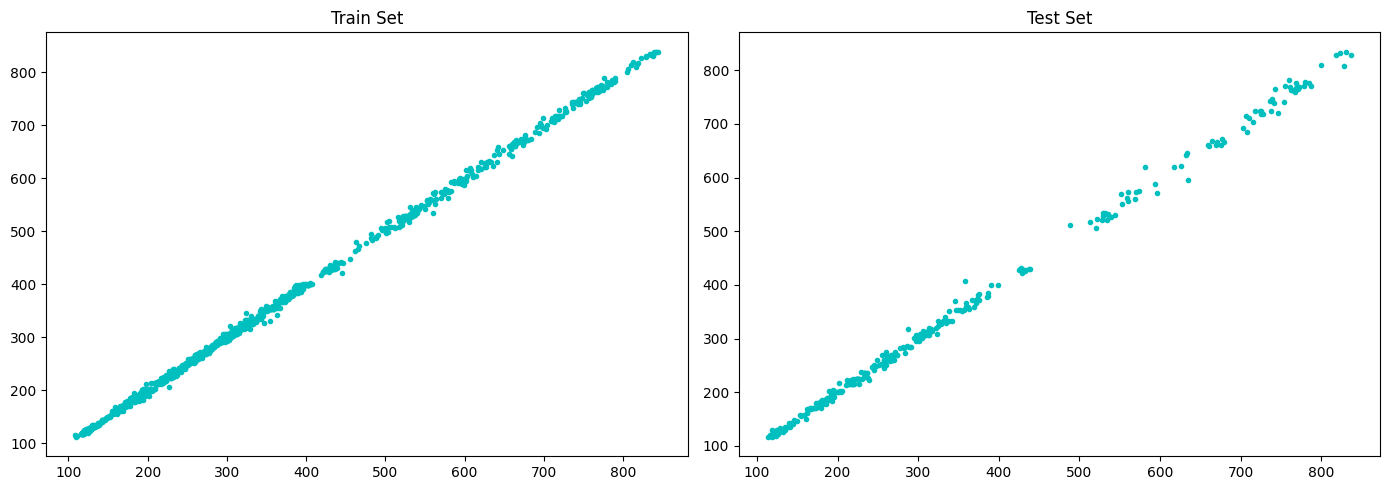


GradientBoostingRegressor(max_depth=5)
r2_train:   0.99985
r2_test:    0.99823
rmse_train: 2.3114
rmse_test:  8.3953


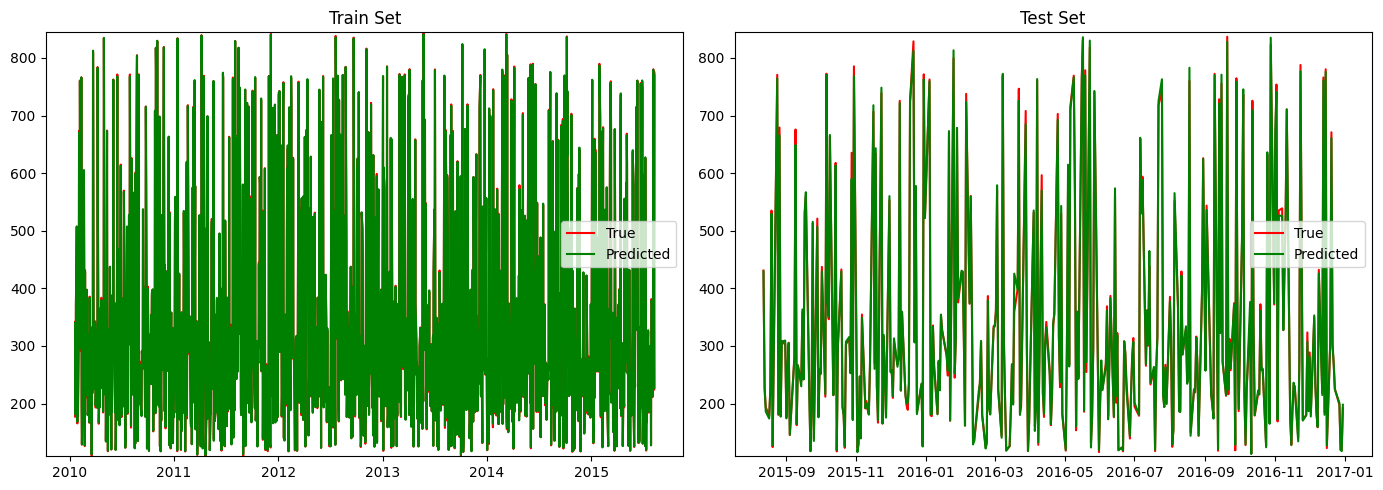

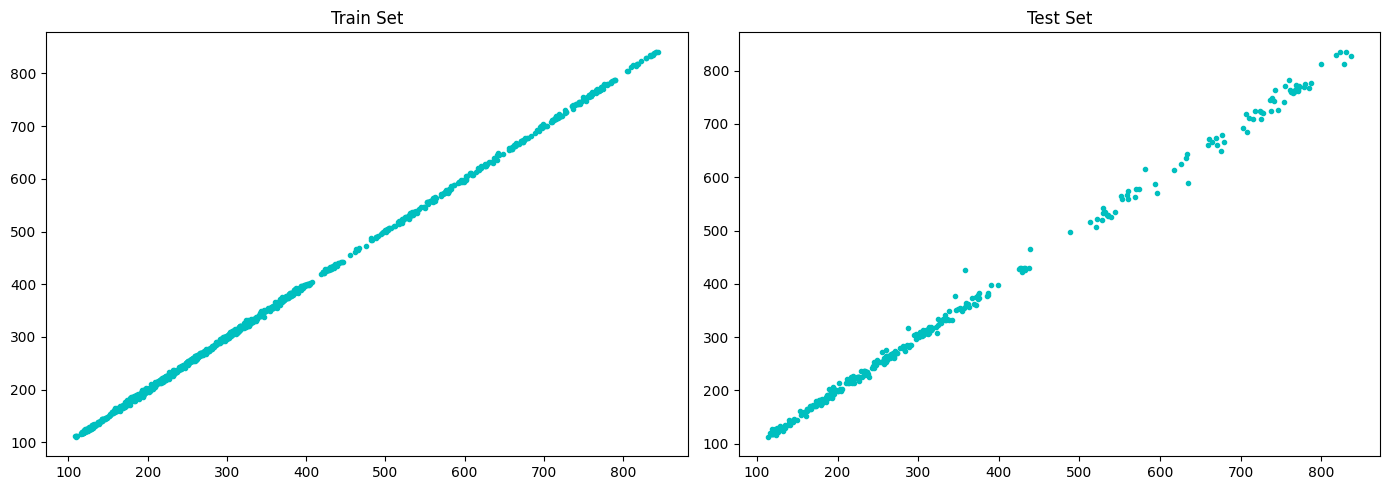

,r2_train,r2_test,rmse_train,rmse_test
model,,,,
LinearRegression(),0.998612,0.998397,6.937483,7.980559
KNeighborsRegressor(n_neighbors=4),0.998145,0.996585,8.021679,11.648717
"RandomForestRegressor(max_depth=5, n_estimators=10)",0.998737,0.998404,6.617594,7.963455
"RandomForestRegressor(max_depth=10, n_estimators=30)",0.999692,0.998391,3.267056,7.995729
GradientBoostingRegressor(max_depth=2),0.999133,0.998240,5.482612,8.362632
GradientBoostingRegressor(),0.999446,0.998431,4.384176,7.895967
GradientBoostingRegressor(max_depth=5),0.999846,0.998226,2.311351,8.395330


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Initialize list to hold results
results = []

for m in models:
    m.fit(X_lasso_train, y_train)

    y_train_pred = m.predict(X_lasso_train)
    y_test_pred  = m.predict(X_lasso_test)

    print(m)

    r2_train = r2_score(y_train, y_train_pred)
    print(f'r2_train:   {r2_train:.5}')

    r2_test = r2_score(y_test, y_test_pred)
    print(f'r2_test:    {r2_test:.5}')

    rmse_train = mean_squared_error(y_train, y_train_pred)**0.5
    print(f'rmse_train: {rmse_train:.5}')

    rmse_test = mean_squared_error(y_test, y_test_pred)**0.5
    print(f'rmse_test:  {rmse_test:.5}')

    # Store in results list
    results.append({
        'model': str(m),
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    })

    # Since y_train_pred and y_test_pred are now 1D, we can directly create pd.Series
    y_train_pred_series = pd.Series(y_train_pred, index=dates_train)
    y_test_pred_series  = pd.Series(y_test_pred, index=dates_test)

    # Calculate global y-axis limits (y_train and y_test are now 1D)
    y_min = min(y_train.min(), y_train_pred_series.min(), y_test.min(), y_test_pred_series.min())
    y_max = max(y_train.max(), y_train_pred_series.max(), y_test.max(), y_test_pred_series.max())

    # Plot train and test side by side with shared y limits
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(dates_train, y_train, 'r', label='True')
    axs[0].plot(y_train_pred_series, 'g', label='Predicted')
    axs[0].set_title('Train Set')
    axs[0].set_ylim(y_min, y_max)
    axs[0].legend()

    axs[1].plot(dates_test, y_test, 'r', label='True')
    axs[1].plot(y_test_pred_series, 'g', label='Predicted')
    axs[1].set_title('Test Set')
    axs[1].set_ylim(y_min, y_max)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Plot train and test side by side with shared y limits
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(y_train, y_train_pred, 'c.')
    axs[0].set_title('Train Set')
    # Removed redundant legend call as no labels are defined for scatter plot
    # axs[0].legend()

    axs[1].plot(y_test, y_test_pred, 'c.')
    axs[1].set_title('Test Set')
    # Removed redundant legend call as no labels are defined for scatter plot
    # axs[1].legend()

    plt.tight_layout()
    plt.show()

    print()
# end

# Create DataFrame
results_df = pd.DataFrame(results)

# Show or sort results
results_df = results_df.set_index("model")
results_df

### Model Evaluation without Lasso Scaling (using `X_pars`)

In [ ]:
# Split X_pars into training and testing sets based on the same split_idx
# y_train, y_test, dates_train, and dates_test are already consistent with this split.
X_pars_train = X_pars.iloc[:split_idx]
X_pars_test = X_pars.iloc[split_idx:]

print(f"Train: X_pars={X_pars_train.shape}, y={y_train.shape}")
print(f"Test:  X_pars={X_pars_test.shape}, y={y_test.shape}")

Train: X_pars=(1401, 50), y=(1401,)
Test:  X_pars=(351, 50), y=(351,)



Evaluating model: LinearRegression()
r2_train:   0.027775
r2_test:    -0.13699
rmse_train: 183.64
rmse_test:  212.56


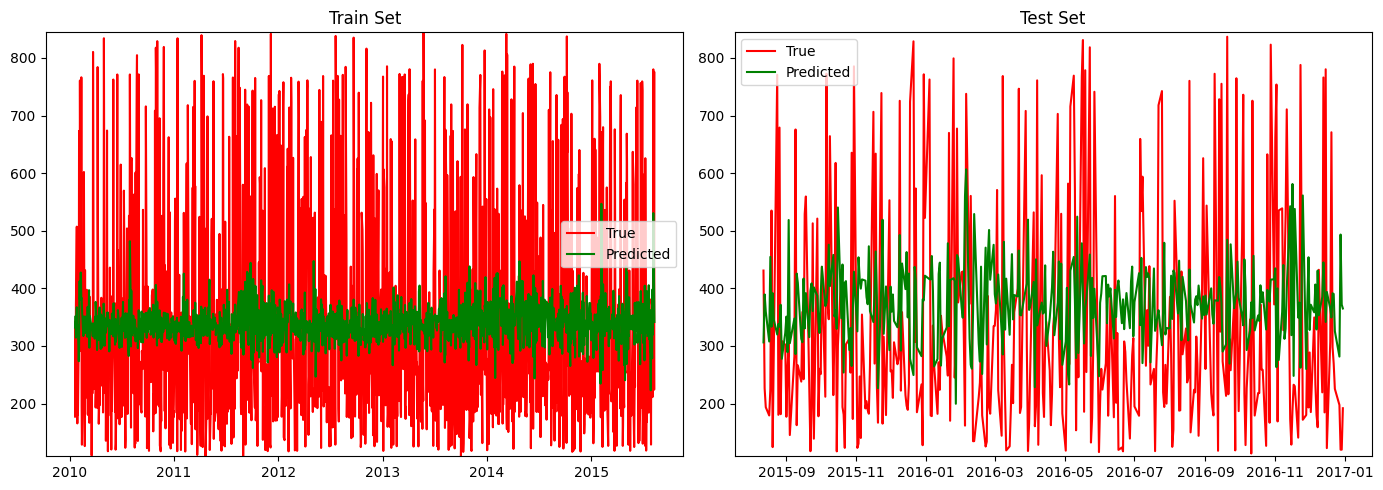

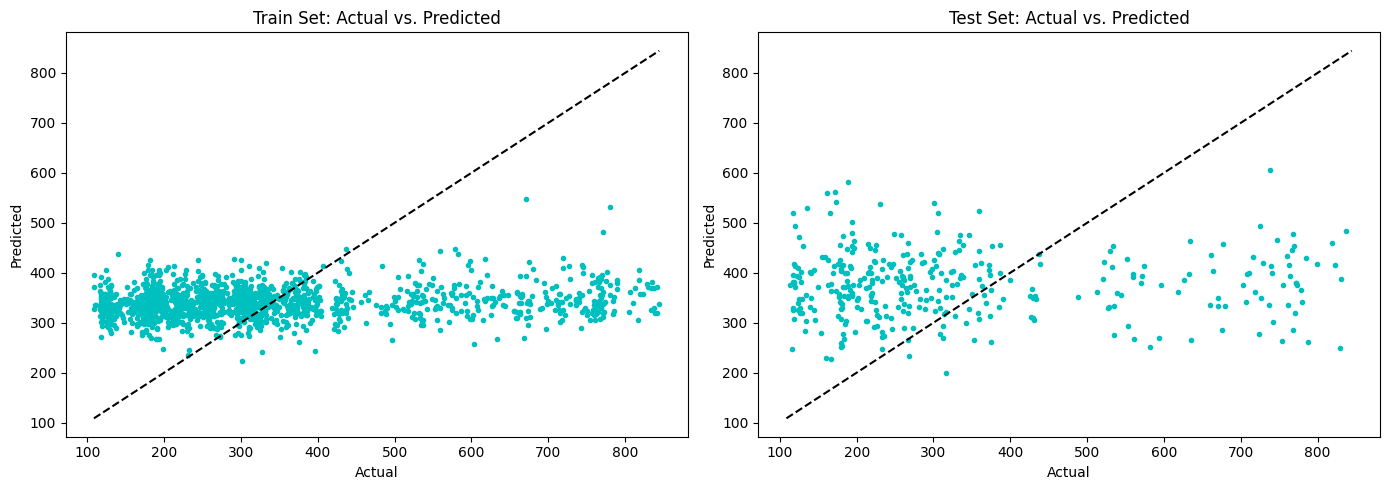


Evaluating model: KNeighborsRegressor(n_neighbors=4)
r2_train:   0.21378
r2_test:    -0.19888
rmse_train: 165.14
rmse_test:  218.27


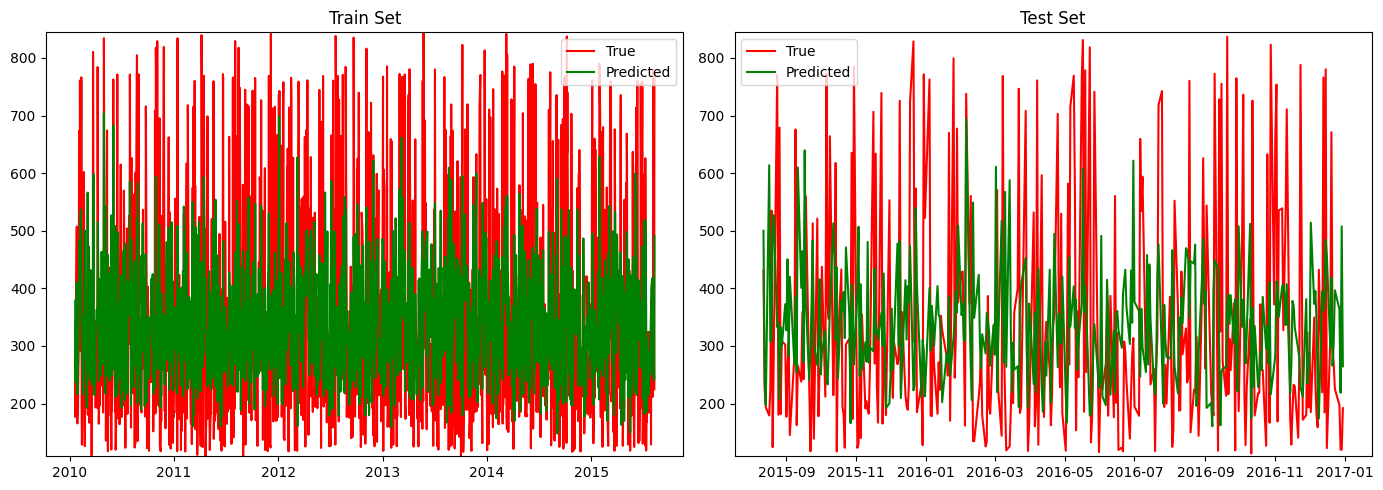

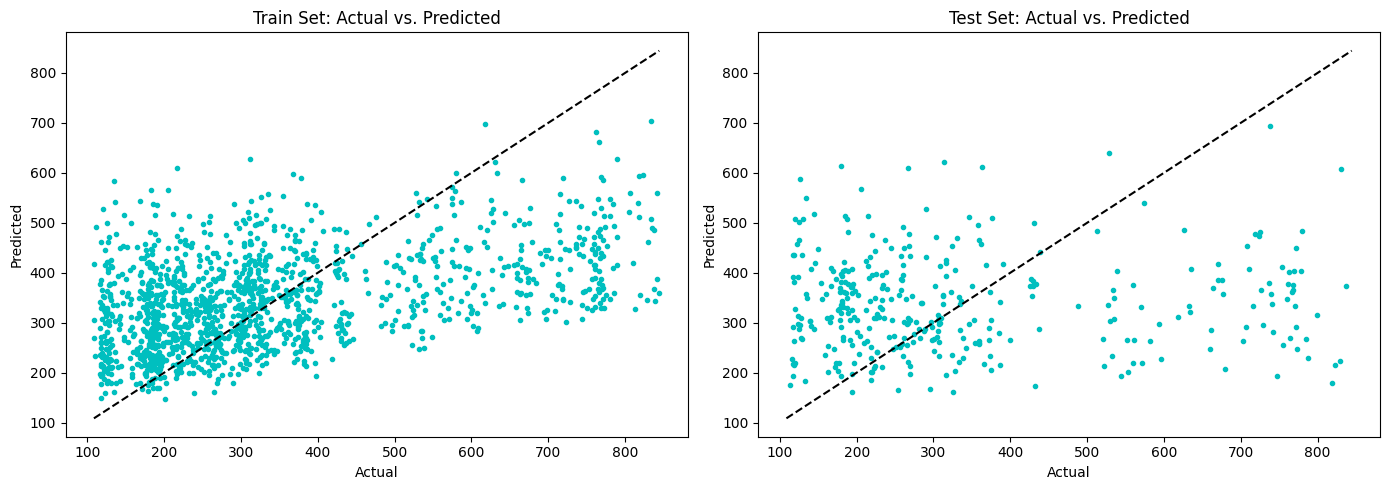


Evaluating model: RandomForestRegressor(max_depth=5, n_estimators=10)
r2_train:   0.13633
r2_test:    -0.58224
rmse_train: 173.08
rmse_test:  250.75


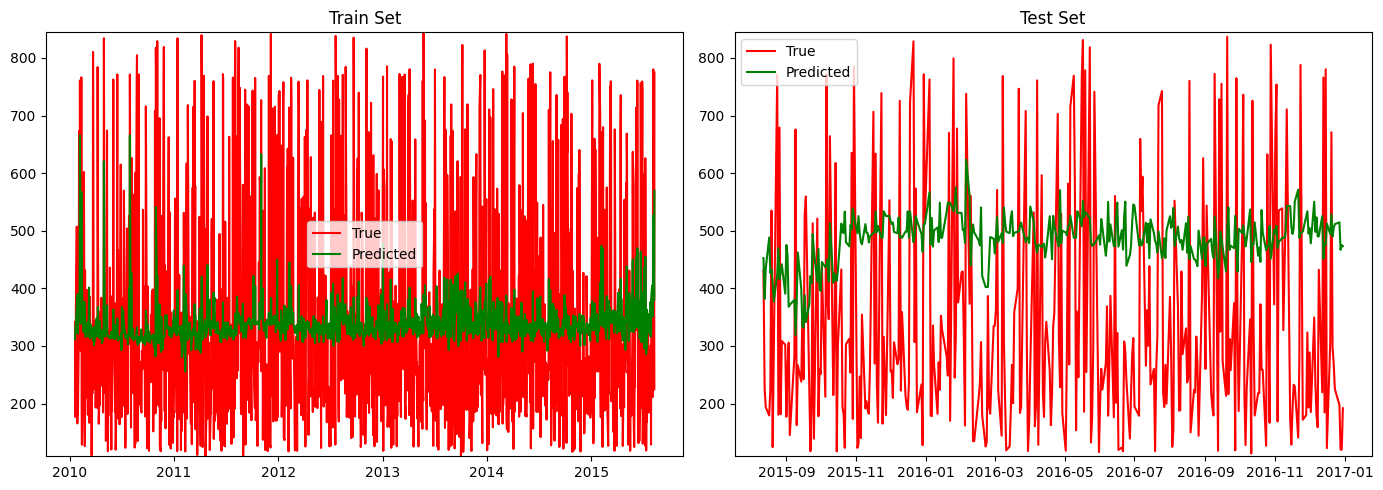

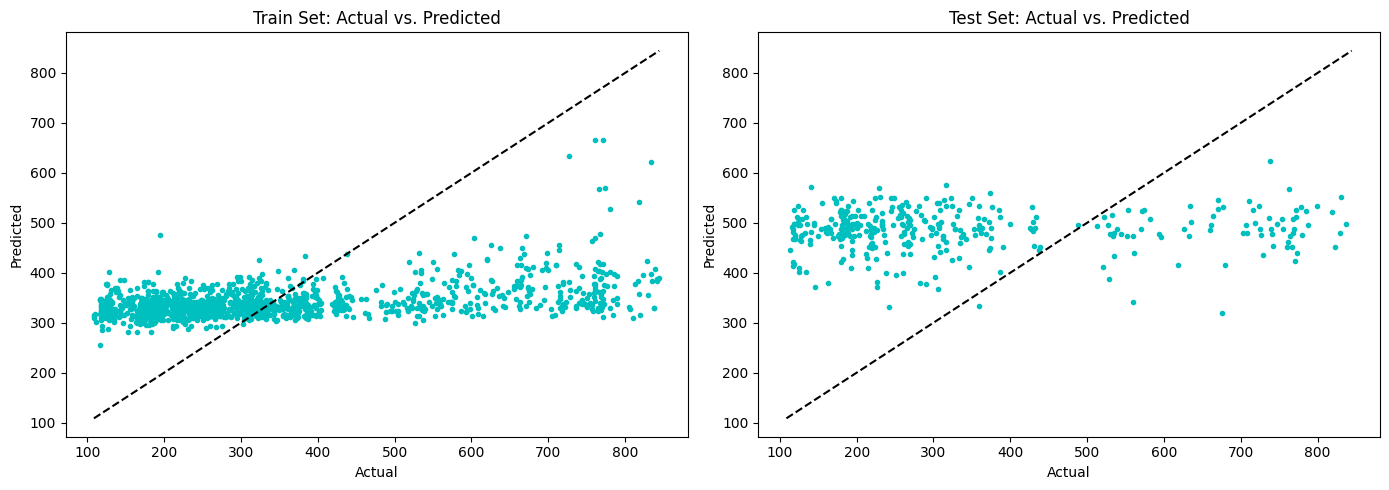


Evaluating model: RandomForestRegressor(max_depth=10, n_estimators=30)
r2_train:   0.37645
r2_test:    -0.86209
rmse_train: 147.06
rmse_test:  272.02


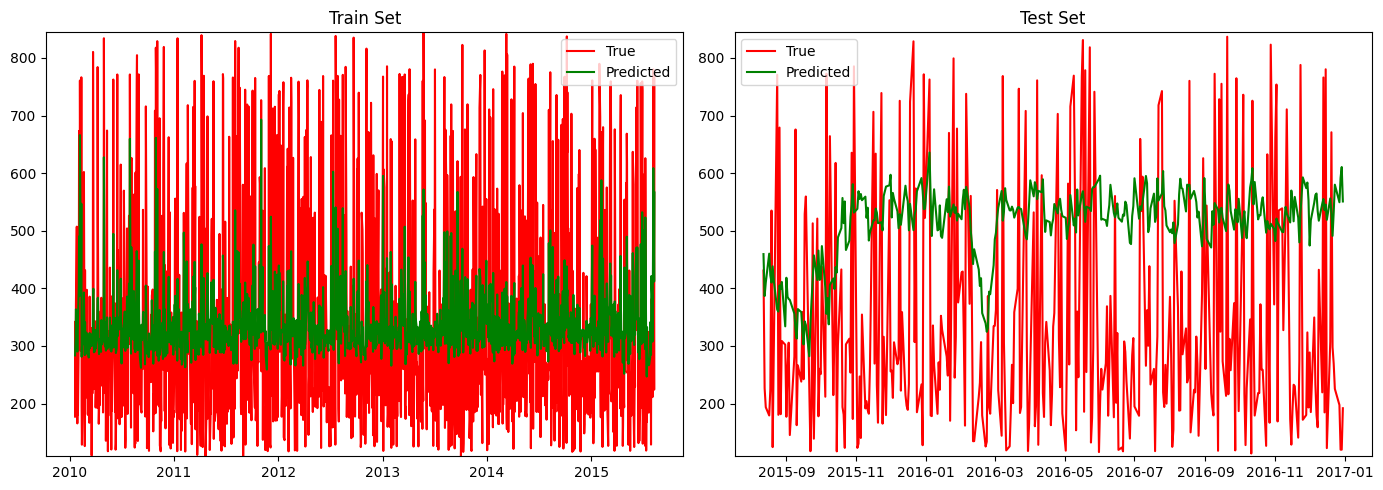

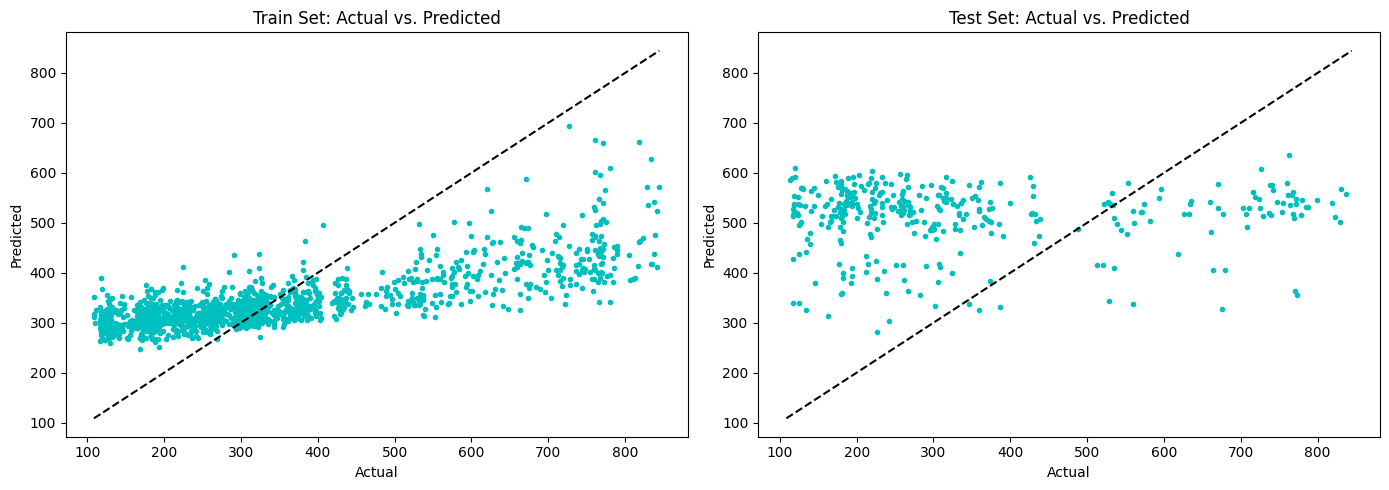


Evaluating model: GradientBoostingRegressor(max_depth=2)
r2_train:   0.17257
r2_test:    -1.3753
rmse_train: 169.41
rmse_test:  307.23


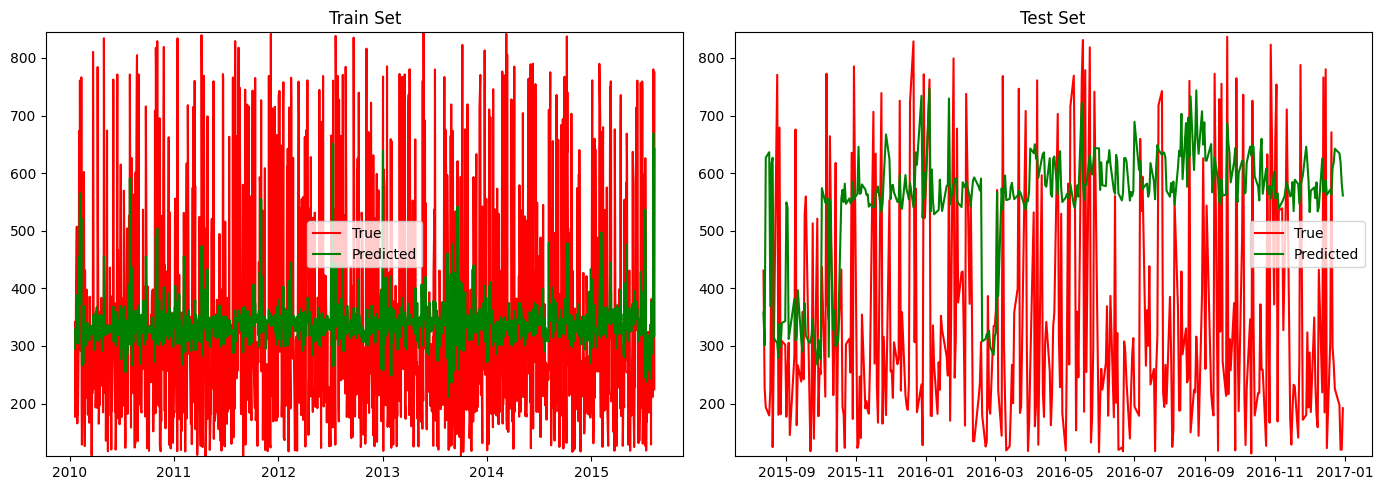

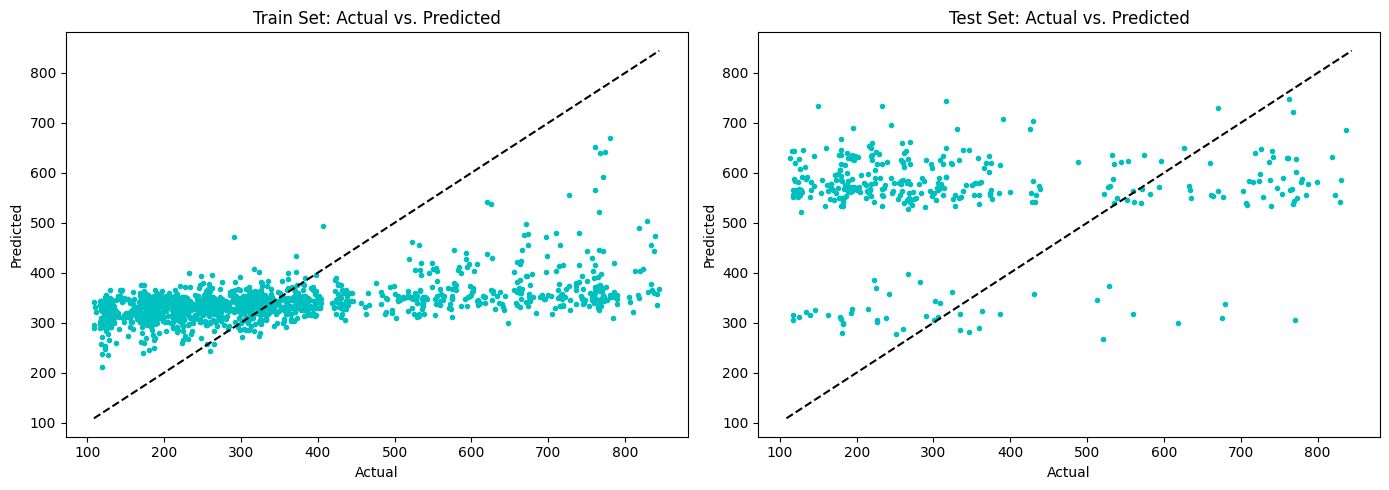


Evaluating model: GradientBoostingRegressor()
r2_train:   0.32072
r2_test:    -1.56
rmse_train: 153.5
rmse_test:  318.95


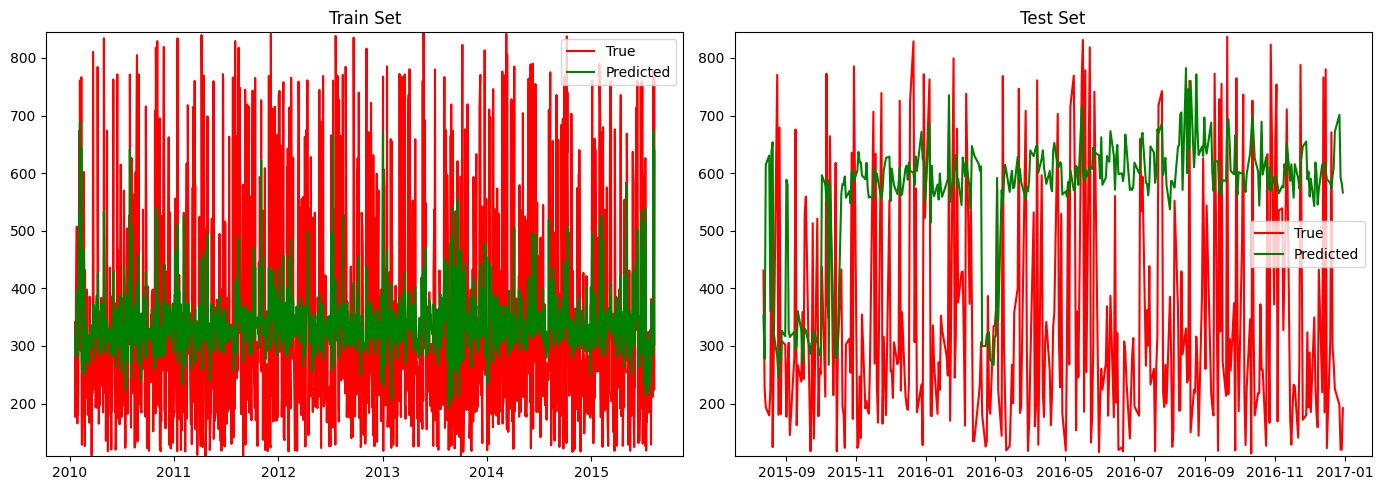

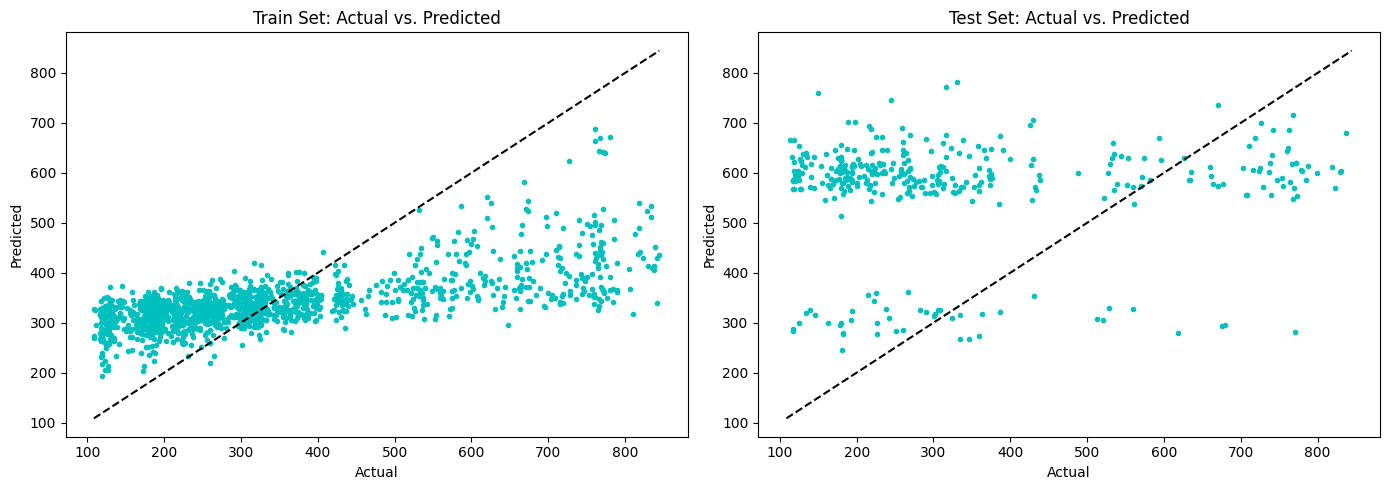


Evaluating model: GradientBoostingRegressor(max_depth=5)
r2_train:   0.63972
r2_test:    -2.0814
rmse_train: 111.79
rmse_test:  349.93


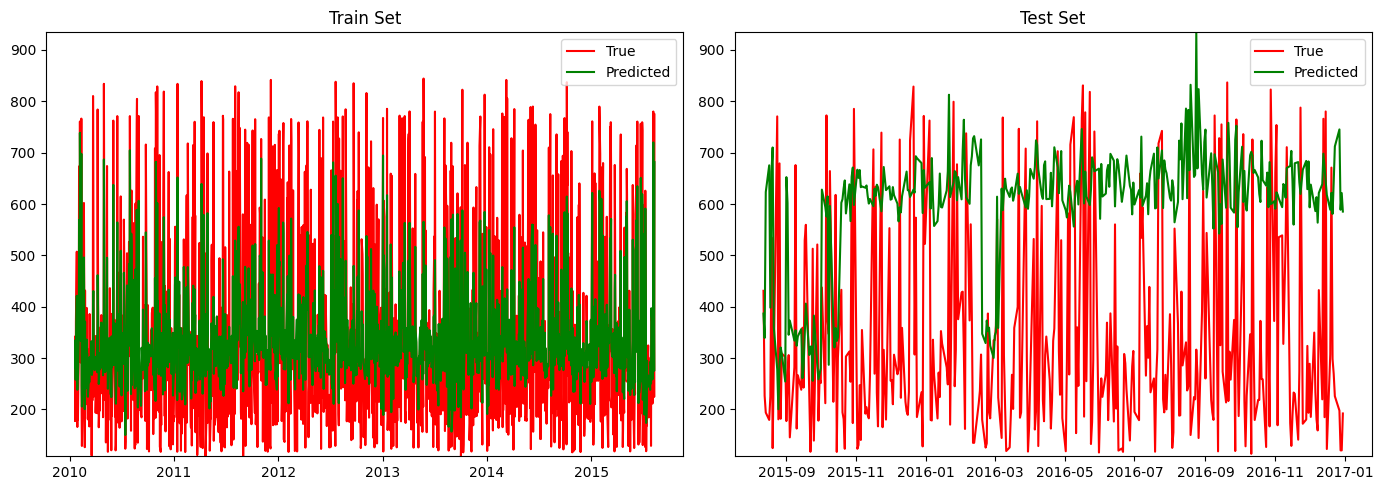

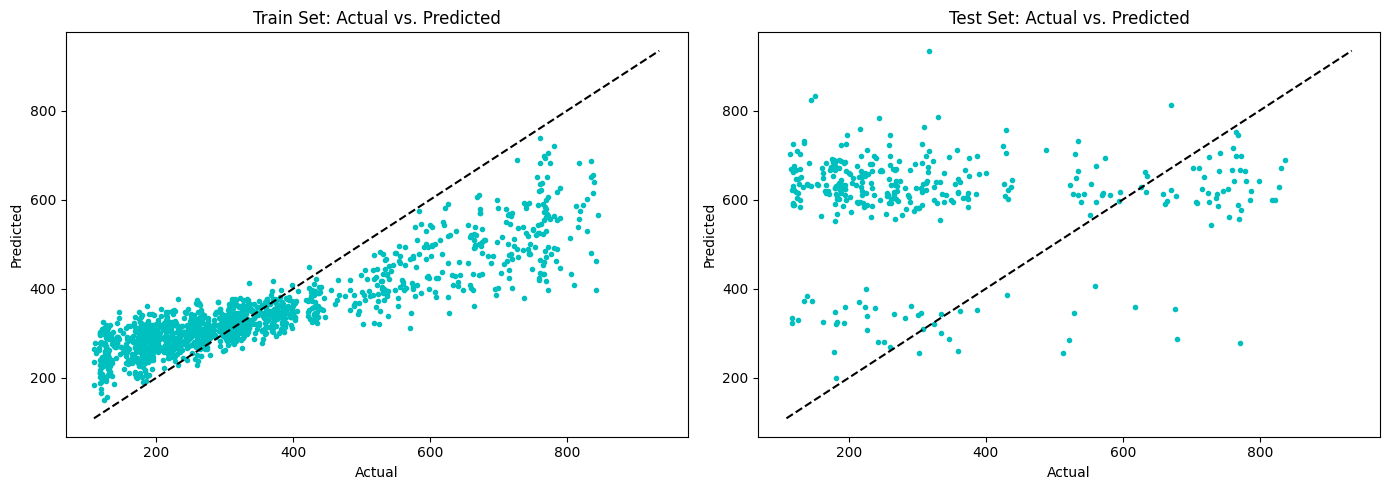

,r2_train,r2_test,rmse_train,rmse_test
model,,,,
LinearRegression(),0.027775,-0.136993,183.635504,212.558021
KNeighborsRegressor(n_neighbors=4),0.213781,-0.198880,165.137268,218.266253
"RandomForestRegressor(max_depth=5, n_estimators=10)",0.136329,-0.582238,173.080265,250.746315
"RandomForestRegressor(max_depth=10, n_estimators=30)",0.376452,-0.862092,147.064662,272.018966
GradientBoostingRegressor(max_depth=2),0.172569,-1.375346,169.410043,307.228962
GradientBoostingRegressor(),0.320724,-1.559995,153.495760,318.946806
GradientBoostingRegressor(max_depth=5),0.639718,-2.081435,111.787817,349.925149


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Initialize list to hold results for this evaluation
results_no_lasso = []

for m in models:
    m.fit(X_pars_train, y_train)

    y_train_pred = m.predict(X_pars_train)
    y_test_pred  = m.predict(X_pars_test)

    print(f"\nEvaluating model: {m}")

    r2_train = r2_score(y_train, y_train_pred)
    print(f'r2_train:   {r2_train:.5}')

    r2_test = r2_score(y_test, y_test_pred)
    print(f'r2_test:    {r2_test:.5}')

    rmse_train = mean_squared_error(y_train, y_train_pred)**0.5
    print(f'rmse_train: {rmse_train:.5}')

    rmse_test = mean_squared_error(y_test, y_test_pred)**0.5
    print(f'rmse_test:  {rmse_test:.5}')

    # Store in results list
    results_no_lasso.append({
        'model': str(m),
        'r2_train': r2_train,
        'r2_test': r2_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test
    })

    # Ensure predictions are Series with dates as index for plotting
    y_train_pred_series = pd.Series(y_train_pred, index=dates_train)
    y_test_pred_series  = pd.Series(y_test_pred, index=dates_test)

    # Calculate global y-axis limits
    y_min = min(y_train.min(), y_train_pred_series.min(), y_test.min(), y_test_pred_series.min())
    y_max = max(y_train.max(), y_train_pred_series.max(), y_test.max(), y_test_pred_series.max())

    # Plot train and test side by side with shared y limits
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(dates_train, y_train, 'r', label='True')
    axs[0].plot(y_train_pred_series, 'g', label='Predicted')
    axs[0].set_title('Train Set')
    axs[0].set_ylim(y_min, y_max)
    axs[0].legend()

    axs[1].plot(dates_test, y_test, 'r', label='True')
    axs[1].plot(y_test_pred_series, 'g', label='Predicted')
    axs[1].set_title('Test Set')
    axs[1].set_ylim(y_min, y_max)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Plot actual vs. predicted values for train and test sets
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(y_train, y_train_pred, 'c.')
    axs[0].set_title('Train Set: Actual vs. Predicted')
    axs[0].set_xlabel('Actual')
    axs[0].set_ylabel('Predicted')
    axs[0].plot([y_min, y_max], [y_min, y_max], 'k--') # Add a diagonal line for perfect prediction

    axs[1].plot(y_test, y_test_pred, 'c.')
    axs[1].set_title('Test Set: Actual vs. Predicted')
    axs[1].set_xlabel('Actual')
    axs[1].set_ylabel('Predicted')
    axs[1].plot([y_min, y_max], [y_min, y_max], 'k--') # Add a diagonal line for perfect prediction

    plt.tight_layout()
    plt.show()

# Create DataFrame from results
results_no_lasso_df = pd.DataFrame(results_no_lasso)

# Show or sort results
results_no_lasso_df = results_no_lasso_df.set_index("model")
display(results_no_lasso_df)

### Comparison: Lasso Scaled vs. Direct `X_pars` Evaluation

In [ ]:
print("Comparison of Model Performance (Lasso-scaled vs. X_pars direct):\n")

for model_name in results_df.index:
    print(f"Model: {model_name}")

    # Results from Lasso-scaled features
    r2_train_lasso = results_df.loc[model_name]['r2_train']
    r2_test_lasso = results_df.loc[model_name]['r2_test']
    rmse_train_lasso = results_df.loc[model_name]['rmse_train']
    rmse_test_lasso = results_df.loc[model_name]['rmse_test']

    # Results from X_pars direct (no Lasso scaling)
    r2_train_no_lasso = results_no_lasso_df.loc[model_name]['r2_train']
    r2_test_no_lasso = results_no_lasso_df.loc[model_name]['r2_test']
    rmse_train_no_lasso = results_no_lasso_df.loc[model_name]['rmse_train']
    rmse_test_no_lasso = results_no_lasso_df.loc[model_name]['rmse_test']

    print(f"  Lasso-Scaled:   R2 (Train={r2_train_lasso:.4f}, Test={r2_test_lasso:.4f}) | RMSE (Train={rmse_train_lasso:.4f}, Test={rmse_test_lasso:.4f})")
    print(f"  X_pars Direct:  R2 (Train={r2_train_no_lasso:.4f}, Test={r2_test_no_lasso:.4f}) | RMSE (Train={rmse_train_no_lasso:.4f}, Test={rmse_test_no_lasso:.4f})")
    print("\n")

Comparison of Model Performance (Lasso-scaled vs. X_pars direct):

Model: LinearRegression()
  Lasso-Scaled:   R2 (Train=0.9986, Test=0.9984) | RMSE (Train=6.9375, Test=7.9806)
  X_pars Direct:  R2 (Train=0.0278, Test=-0.1370) | RMSE (Train=183.6355, Test=212.5580)


Model: KNeighborsRegressor(n_neighbors=4)
  Lasso-Scaled:   R2 (Train=0.9981, Test=0.9966) | RMSE (Train=8.0217, Test=11.6487)
  X_pars Direct:  R2 (Train=0.2138, Test=-0.1989) | RMSE (Train=165.1373, Test=218.2663)


Model: RandomForestRegressor(max_depth=5, n_estimators=10)
  Lasso-Scaled:   R2 (Train=0.9987, Test=0.9984) | RMSE (Train=6.6176, Test=7.9635)
  X_pars Direct:  R2 (Train=0.1363, Test=-0.5822) | RMSE (Train=173.0803, Test=250.7463)


Model: RandomForestRegressor(max_depth=10, n_estimators=30)
  Lasso-Scaled:   R2 (Train=0.9997, Test=0.9984) | RMSE (Train=3.2671, Test=7.9957)
  X_pars Direct:  R2 (Train=0.3765, Test=-0.8621) | RMSE (Train=147.0647, Test=272.0190)


Model: GradientBoostingRegressor(max_depth=2)

I used Lasso regression because:

*   I have many features, and I want to perform automatic feature selection
*   I suspect some features are not truly relevant to the target variable.

*   I need a more interpretable model.
*   I am dealing with multicollinearity among your predictors due to high similar of stock prices







# KERAS: Cross Validation

In [ ]:
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=X_train.shape[1]),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Re-defining build_model with the fix for the Input layer
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Input layer now expects 3D shape
        Flatten(), # Added: Flatten the input for Dense layers
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='linear'), # Changed activation to 'linear' for regression
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

epochs                = 500
batch_size            = 256
decay_frac            = 0.8
dropout_rate          = 0.25
initial_learning_rate = 0.01

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True)

train_mae_list = []
test_mae_list = []
train_r2_list = []
test_r2_list = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}/{n_splits}")
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Scale X_train_fold and y_train_fold for the neural network
    # Flatten X_train_fold and X_test_fold for scaling, then reshape back
    scaler_X = MinMaxScaler(feature_range=(0,1))
    X_train_flat = X_train_fold.reshape(X_train_fold.shape[0], -1)
    X_test_flat = X_test_fold.reshape(X_test_fold.shape[0], -1)

    X_train_scaled = scaler_X.fit_transform(X_train_flat)
    X_test_scaled = scaler_X.transform(X_test_flat)

    X_train_scaled = X_train_scaled.reshape(X_train_fold.shape)
    X_test_scaled = X_test_scaled.reshape(X_test_fold.shape)

    scaler_y = MinMaxScaler(feature_range=(0,1))
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test_fold.reshape(-1, 1))

    # Build a fresh model (which resets optimizer state including the learning rate schedule)
    model = build_model(
        X_train_scaled,
        epochs,
        batch_size,
        decay_frac,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping]
    )

    # Evaluate on training data
    y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled) # Inverse transform predictions
    train_mae = mean_absolute_error(y_train_fold, y_train_pred)
    train_r2 = r2_score(y_train_fold, y_train_pred)

    # Evaluate on test data
    y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled) # Inverse transform predictions
    test_mae = mean_absolute_error(y_test_fold, y_test_pred)
    test_r2 = r2_score(y_test_fold, y_test_pred)

    print("MAE:")
    print(f"  Train: {train_mae:.4f}")
    print(f"  Test:  {test_mae:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2:.4f}")
    print(f"  Test:  {test_r2:.4f}")
    print()

    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    fold += 1
# end

Fold 1/5
MAE:
  Train: 37.0084
  Test:  36.8437
R^2:
  Train: 0.9172
  Test:  0.9172

Fold 2/5
MAE:
  Train: 50.2371
  Test:  48.2925
R^2:
  Train: 0.8562
  Test:  0.8623

Fold 3/5
MAE:
  Train: 72.8824
  Test:  72.9674
R^2:
  Train: 0.7148
  Test:  0.7007

Fold 4/5
MAE:
  Train: 75.2030
  Test:  78.8043
R^2:
  Train: 0.6884
  Test:  0.6746

Fold 5/5
MAE:
  Train: 40.7617
  Test:  42.2623
R^2:
  Train: 0.9108
  Test:  0.9152



In [ ]:
results_df = pd.DataFrame({
    'Train MAE': train_mae_list,
    'Test MAE': test_mae_list,
    'Train R2': train_r2_list,
    'Test R2': test_r2_list
})

results_df.describe()

,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,55.218510,55.834033,0.817467,0.813997
std,17.866238,18.860588,0.108785,0.117791
min,37.008401,36.843660,0.688427,0.674554
25%,40.761745,42.262304,0.714800,0.700743
50%,50.237097,48.292478,0.856160,0.862264
75%,72.882354,72.967448,0.910780,0.915244
max,75.202951,78.804275,0.917170,0.917182


# Train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pars, y,
                                                    test_size=0.2)

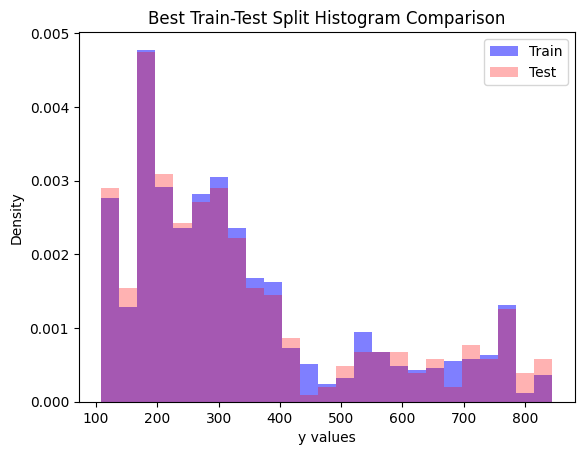

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


# Define the number of attempts
attempts = 1000

# Determine the global min and max of y
y_min, y_max = y.min(), y.max()
bins = np.linspace(y_min, y_max, 26)  # 25 bins means 26 edges

best_mse = float('inf')
best_split = None

for i in range(attempts):
    # Perform train-test split
    X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_pars, y, test_size=0.2)

    # Compute histograms
    y_train_hist, _ = np.histogram(y_train_i, bins=bins, density=True)
    y_test_hist, _ = np.histogram(y_test_i, bins=bins, density=True)

    # Compute MSE between histograms
    mse = mean_squared_error(y_train_hist, y_test_hist)

    # Save the best split
    if mse < best_mse:
        best_mse = mse
        best_split = (X_train_i, X_test_i, y_train_i, y_test_i)

# Unpack the best split
X_train, X_test, y_train, y_test = best_split

# Display histograms of the best split
plt.hist(y_train, bins=bins, alpha=0.5, color='b', label='Train', density=True)
plt.hist(y_test, bins=bins, alpha=0.3, color='r', label='Test', density=True)
plt.legend()
plt.xlabel('y values')
plt.ylabel('Density')
plt.title('Best Train-Test Split Histogram Comparison')
plt.show()

# Model Creation

In [ ]:
dropout_rate = 0.1

model_dense  = Sequential([
    Input(shape=(X_train.shape[1],)), # Corrected input shape

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(8, activation='relu'),

    Dense(1, activation='linear'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model_dense .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_dense .summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,401 (9.38 KB)

 Non-trainable params: 96 (384.00 B)

# Learning rate schedule

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

# Early stopping and learning rate reduction callback

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [ ]:
history_dense = model_dense .fit(
    X_train, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - loss: 337.5316 - val_loss: 307.1129
Epoch 2/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 329.8145 - val_loss: 227.2483
Epoch 3/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 302.3319 - val_loss: 241.1556
Epoch 4/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 254.7625 - val_loss: 174.0533
Epoch 5/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 160.0587 - val_loss: 150.9929
Epoch 6/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 128.8304 - val_loss: 156.1977
Epoch 7/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 127.1937 - val_loss: 135.7344
Epoch 8/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 127.2160 - val_loss: 135.3692
Epoch 9/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 126.3275 - val_loss: 129.4238
Epoch 10/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 126.0374 - val_loss: 127.9008
Epoch 11/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 125.6575 - val_loss: 125.9055
Epoch 12/150
22/2

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
r2_train:   0.95258
r2_test:    0.80395
rmse_train: 40.759
rmse_test:  86.73


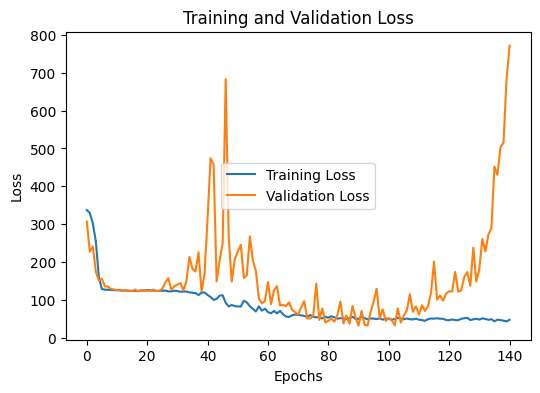

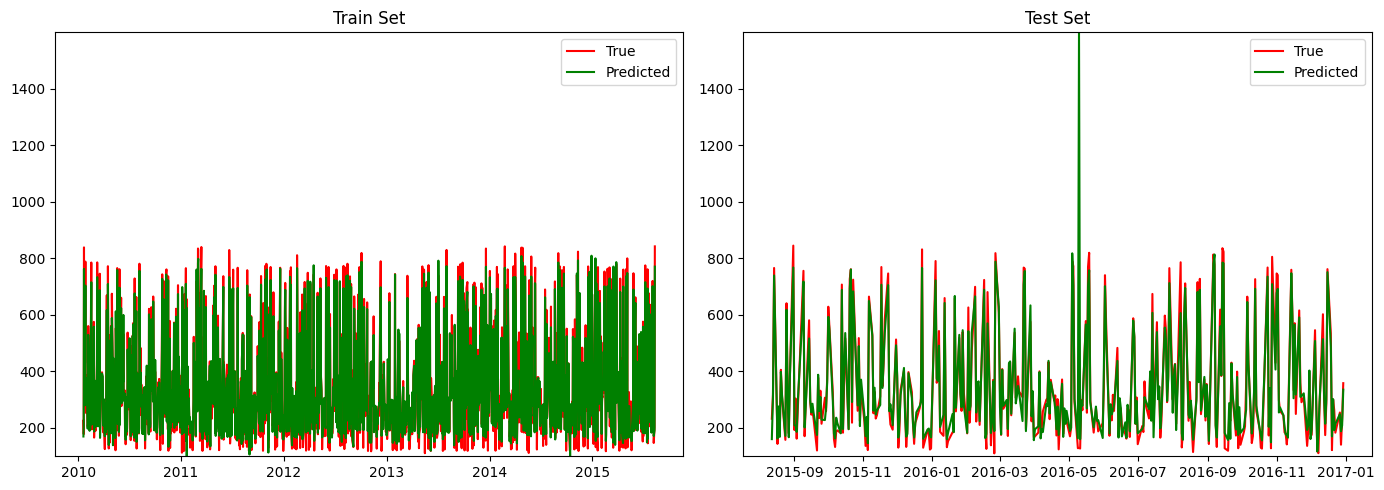

/tmp/ipykernel_1980/3262281577.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/tmp/ipykernel_1980/3262281577.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


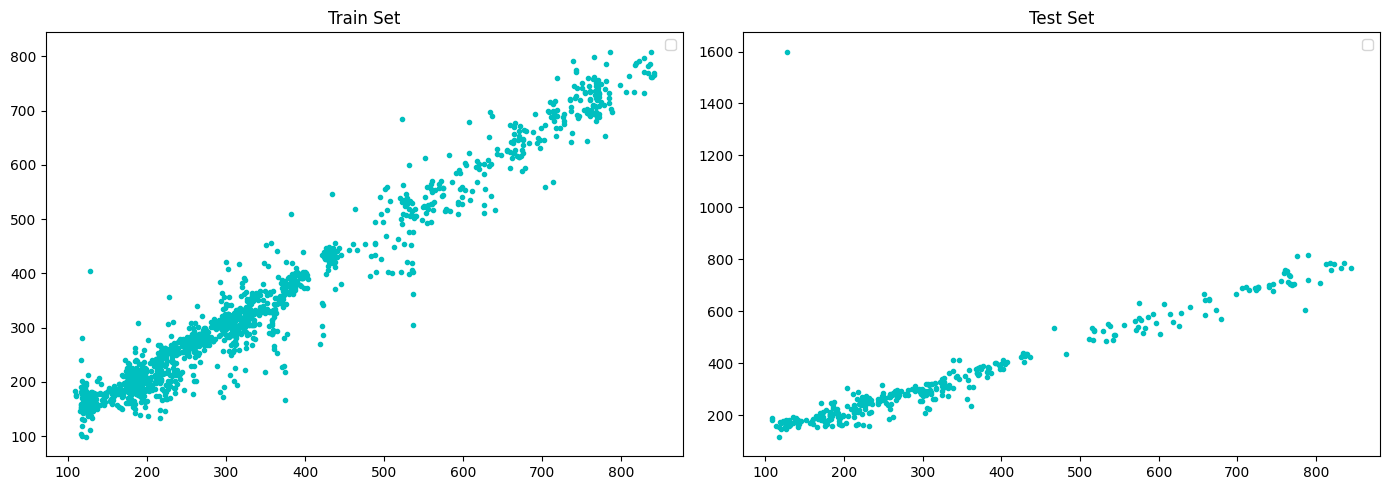

MAE:
  Train: 29.3829
  Test:  32.0577
R^2:
  Train: 0.9526
  Test:  0.8040


In [ ]:
# Get predictions
y_train_pred = model_dense.predict(X_train)[:,0]
y_test_pred  = model_dense.predict(X_test)[:,0]

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Left subplot: Training and Validation Loss
ax.plot(history_dense.history['loss'], label='Training Loss')
ax.plot(history_dense.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()

r2_train = r2_score(y_train, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

y_train_pred = pd.Series(y_train_pred, index=dates_train)
y_test_pred  = pd.Series(y_test_pred, index=dates_test)

# Calculate global y-axis limits
y_min = min(y_train.min(), y_train_pred.min(), y_test.min(), y_test_pred.min())
y_max = max(y_train.max(), y_train_pred.max(), y_test.max(), y_test_pred.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train, y_train, 'r', label='True')
axs[0].plot(y_train_pred, 'g', label='Predicted')
axs[0].set_title('Train Set')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test, y_test, 'r', label='True')
axs[1].plot(y_test_pred, 'g', label='Predicted')
axs[1].set_title('Test Set')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train, y_train_pred.values, 'c.')
axs[0].set_title('Train Set')
axs[0].legend()

axs[1].plot(y_test, y_test_pred.values, 'c.')
axs[1].set_title('Test Set')
axs[1].legend()

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

### Fixing Data Alignment for `predicted_results_df`

The previous `train_test_split` operation in cell `csEeNYwzbbXj` shuffled the data to find an optimal split for histogram distribution. However, this shuffling caused a misalignment between the `y_test` values and their corresponding `dates_test` when attempting to display the final prediction results chronologically.

To correct this, I will perform a new chronological train-test split using `X_pars` (the feature-selected, scaled features) and `y` (the original unscaled close prices). Then, I will retrain the `model_dense` on this chronologically ordered data and generate new predictions. This ensures that the 'open' price, 'Actual Close Price', and 'Predicted Stock Price' in the `predicted_results_df` are all correctly aligned by date.

In [ ]:
# Re-establish chronological train-test split using X_pars and y
# Using the split_idx defined in cell DB1qMLlP0e_7
split_idx = int(len(X) * 0.8)

X_train_chrono = X_pars.iloc[:split_idx]
X_test_chrono = X_pars.iloc[split_idx:]

y_train_chrono = y[:split_idx]
y_test_chrono = y[split_idx:]

dates_train_chrono = dates[:split_idx]
dates_test_chrono = dates[split_idx:]

print(f"Chronological Train: X_pars={X_train_chrono.shape}, y={y_train_chrono.shape}, dates={dates_train_chrono.shape}")
print(f"Chronological Test:  X_pars={X_test_chrono.shape}, y={y_test_chrono.shape}, dates={dates_test_chrono.shape}")

Chronological Train: X_pars=(1401, 50), y=(1401,), dates=(1401,)
Chronological Test:  X_pars=(351, 50), y=(351,), dates=(351,)


### Retraining `model_dense` with Chronological Data

Now, I will retrain the `model_dense` using the newly created chronological training and testing sets. This ensures that the predictions (`y_test_pred_chrono`) will also be in chronological order and correctly align with their corresponding `dates_test_chrono` and original `Amazon` data.

In [ ]:
# Retrain model_dense with chronological split
history_dense_chrono = model_dense.fit(
    X_train_chrono,
    y_train_chrono,
    epochs=100, # Use the same epochs as before
    batch_size=64, # Use the same batch_size as before
    validation_data=(X_test_chrono, y_test_chrono),
    verbose=0, # Set verbose to 0 to suppress output during training
    callbacks=[early_stopping] # Use the early_stopping callback defined previously
)

# Generate predictions using the chronologically ordered test set
y_train_pred_chrono = model_dense.predict(X_train_chrono)[:,0]
y_test_pred_chrono  = model_dense.predict(X_test_chrono)[:,0]

# Evaluate the model with chronological data
r2_train_chrono = r2_score(y_train_chrono, y_train_pred_chrono)
r2_test_chrono = r2_score(y_test_chrono, y_test_pred_chrono)
rmse_train_chrono = mean_squared_error(y_train_chrono, y_train_pred_chrono)**0.5
rmse_test_chrono = mean_squared_error(y_test_chrono, y_test_pred_chrono)**0.5

print("Model performance with chronological split:")
print(f'  R2 Train: {r2_train_chrono:.5f}')
print(f'  R2 Test:  {r2_test_chrono:.5f}')
print(f'  RMSE Train: {rmse_train_chrono:.5f}')
print(f'  RMSE Test:  {rmse_test_chrono:.5f}')

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Model performance with chronological split:
  R2 Train: 0.12272
  R2 Test:  -8.03056
  RMSE Train: 84.40244
  RMSE Test:  298.02129


### Generating the Corrected `predicted_results_df`

Now, all components are aligned. I will construct the `predicted_results_df` using the `y_test_chrono`, `y_test_pred_chrono`, and `dates_test_chrono` to ensure accuracy and proper date alignment. The 'open' prices will also be correctly retrieved for `dates_test_chrono` from the `Amazon` DataFrame.

In [ ]:
# Create a DataFrame to organize the data of true vs pred data graph
predicted_results_df_corrected = pd.DataFrame({
    'Actual Close Price': pd.Series(y_test_chrono, index=dates_test_chrono), # Ensure y_test is correctly aligned by date
    'Predicted Stock Price': pd.Series(y_test_pred_chrono, index=dates_test_chrono),
    'Difference (Error)': (pd.Series(y_test_chrono, index=dates_test_chrono) - pd.Series(y_test_pred_chrono, index=dates_test_chrono)),
    'Percentage Error (%)': ((abs(pd.Series(y_test_chrono, index=dates_test_chrono) - pd.Series(y_test_pred_chrono, index=dates_test_chrono)) / pd.Series(y_test_chrono, index=dates_test_chrono)) * 100)
})

# Get the original 'open' prices from the Amazon DataFrame using dates_test_chrono's index
open_prices_chrono = Amazon.loc[dates_test_chrono, ['open']]

# Merge this information into predicted_results_df, aligning by index
predicted_results_df_corrected = predicted_results_df_corrected.merge(open_prices_chrono, left_index=True, right_index=True)

# Reorder columns for clarity, putting 'open' and 'Actual Close Price' first
predicted_results_df_corrected = predicted_results_df_corrected[[
    'open', 'Actual Close Price', 'Predicted Stock Price',
    'Difference (Error)', 'Percentage Error (%)'
]]

# Display the corrected numerical table
display(predicted_results_df_corrected)

,open,Actual Close Price,Predicted Stock Price,Difference (Error),Percentage Error (%)
2015-08-12,523.750000,525.909973,308.116577,217.793396,41.412677
2015-08-13,527.369995,529.659973,305.849182,223.810791,42.255561
2015-08-14,528.250000,531.520020,315.850830,215.669190,40.575930
2015-08-17,531.289978,535.219971,322.523773,212.696198,39.739959
2015-08-18,535.039978,535.020020,313.253387,221.766633,41.450156
...,...,...,...,...,...
2016-12-23,764.549988,760.590027,436.403900,324.186127,42.622979
2016-12-27,763.400024,771.400024,423.820984,347.579040,45.058210
2016-12-28,776.250000,772.130005,405.746521,366.383484,47.451010
2016-12-29,772.400024,765.150024,410.099243,355.050781,46.402767


#LSTM

# Learning rate schedule

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [ ]:
X_train_2 = X_train.values.reshape((X_train.shape[0], window_size, X_train.shape[1] // window_size))
X_test_2 = X_test.values.reshape((X_test.shape[0], window_size, X_test.shape[1] // window_size))

model_lstm = Sequential([
    Input(shape=(window_size, X_train.shape[1] // window_size)), # Corrected input shape

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.001)

# Compile model
model_lstm .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm .summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
history_lstm = model_lstm.fit(
    X_train_2, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_2, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 338.5126 - val_loss: 339.3181
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 336.5088 - val_loss: 334.7272
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 329.7943 - val_loss: 325.8164
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 320.3057 - val_loss: 316.2947
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 309.9596 - val_loss: 305.5406
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 298.7819 - val_loss: 293.5371
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 286.0508 - val_loss: 280.1041
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 271.6248 - val_loss: 265.1486
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 256.0014 - val_loss: 248.6492
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 239.0085 - val_loss: 230.6699
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 220.7950 - val_loss: 212.3806
Epoch 12

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
r2_train:   0.95529
r2_test:    0.7092
rmse_train: 19.055
rmse_test:  53.479


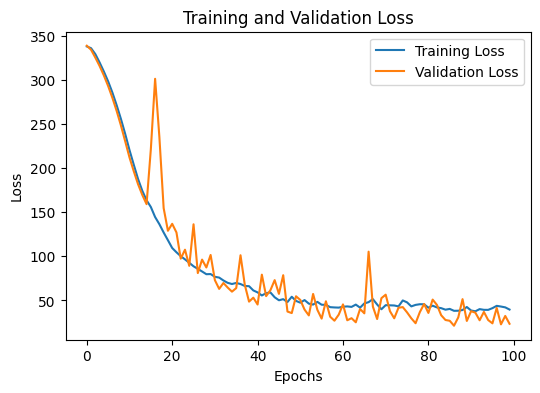

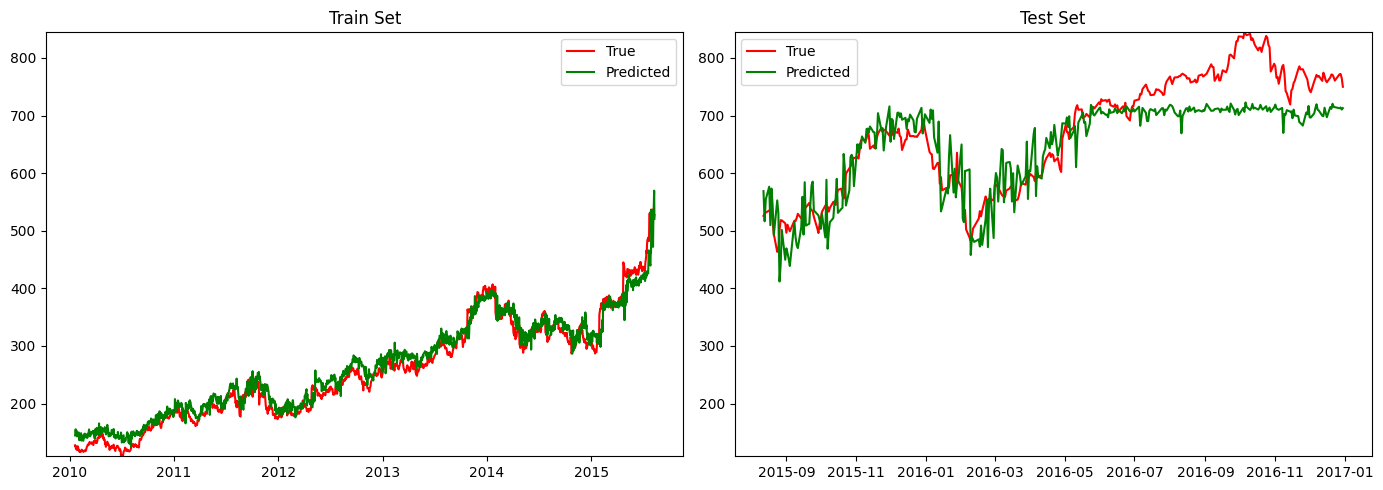

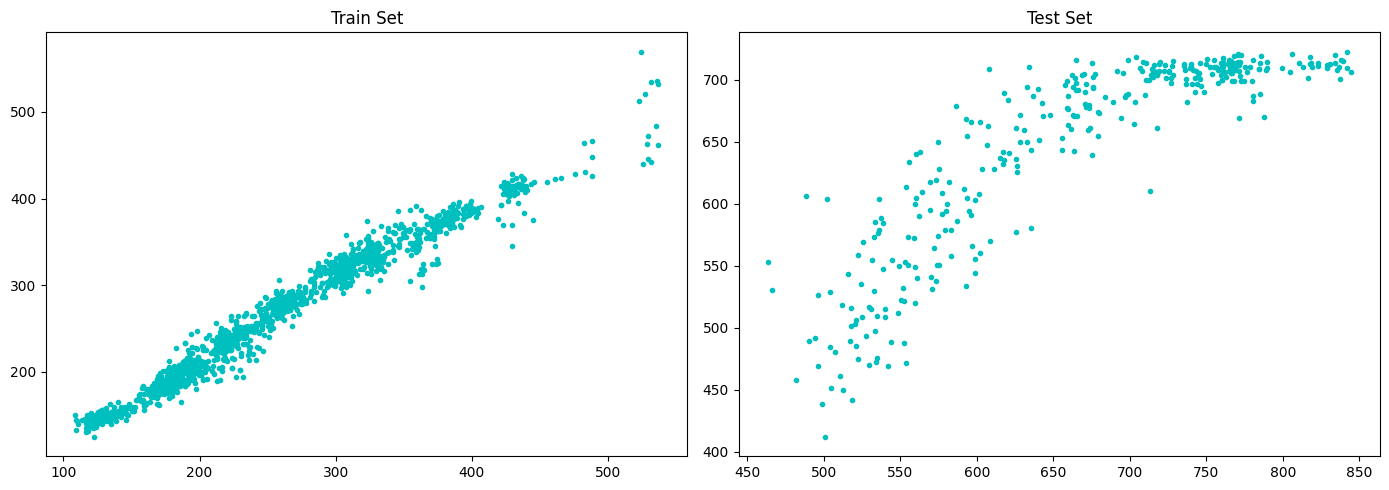

MAE:
  Train: 29.3829
  Test:  32.0577
R^2:
  Train: 0.9553
  Test:  0.7092


In [ ]:
# Get predictions
# Reshape chronological X_train_chrono and X_test_chrono (which are 2D DataFrames)
# into the 3D format expected by the LSTM model.
# window_size is 10, and X_train_chrono.shape[1] // window_size = 50 // 10 = 5
X_train_lstm_input = X_train_chrono.values.reshape((X_train_chrono.shape[0], window_size, X_train_chrono.shape[1] // window_size))
X_test_lstm_input = X_test_chrono.values.reshape((X_test_chrono.shape[0], window_size, X_test_chrono.shape[1] // window_size))

y_train_pred = model_lstm.predict(X_train_lstm_input)[:,0]
y_test_pred  = model_lstm.predict(X_test_lstm_input)[:,0]

# Now use the chronological true values and dates for all subsequent calculations and plotting
y_train_true = y_train_chrono
y_test_true = y_test_chrono
dates_train_plot = dates_train_chrono
dates_test_plot = dates_test_chrono

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Left subplot: Training and Validation Loss
ax.plot(history_lstm.history['loss'], label='Training Loss')
ax.plot(history_lstm.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()

r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

y_train_pred = pd.Series(y_train_pred, index=dates_train_plot)
y_test_pred  = pd.Series(y_test_pred, index=dates_test_plot)

# Calculate global y-axis limits
y_min = min(y_train_true.min(), y_train_pred.min(), y_test_true.min(), y_test_pred.min())
y_max = max(y_train_true.max(), y_train_pred.max(), y_test_true.max(), y_test_pred.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred, 'g', label='Predicted')
axs[0].set_title('Train Set')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred, 'g', label='Predicted')
axs[1].set_title('Test Set')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred.values, 'c.')
axs[0].set_title('Train Set')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred.values, 'c.')
axs[1].set_title('Test Set')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")